In [3046]:
using Pkg
using CSV
using DataFrames
using Polynomials
using CairoMakie
using Statistics

In [3047]:
include("D:/01 Projekt/03 Programm/Rini aktuell/Rini/src/TIRA.jl")

Main.TIRA

## Plots

In [3048]:
figStrainRate = Figure(resolution = (800, 600));

font=45
axStrainRate = Axis(figStrainRate[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false,
    limits = ((0,3),nothing)
    )

Axis with 0 plots:


## Proben Geometrie

In [3049]:
## Geometrie
w=10*1e-3 # Width
t=15.5*1e-6 # thickness W3 from the 2nd batch
l=60*1e-3 # length between clamps
As=w*t    # stress section

1.55e-7

## Raum Temperatur

In [3050]:

BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [3051]:
df_260126=[]

Any[]

In [3052]:
DataProperties=[]

Any[]

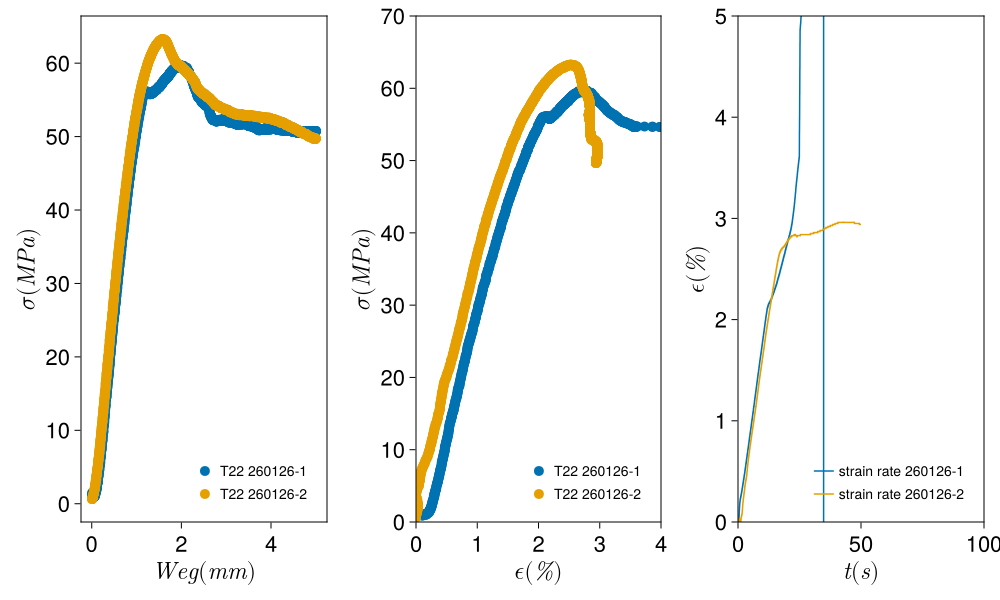

In [3053]:

## Geometrie
w=10*1e-3 # Width
t=15.5*1e-6 # thickness W4 from the 2nd batch
l=60*1e-3 # length between clamps
As=w*t    # stress section

#### Raum T


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [1 2]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T22 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T22 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 100, 0, 5)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [3054]:
ϵ_LinearRange=[0.1 1]
ϵ_range=[0 4]
t_range=[0 100] #in order to avoid wrong measurements from the camera
σ_range=[0 80]
T=22

22

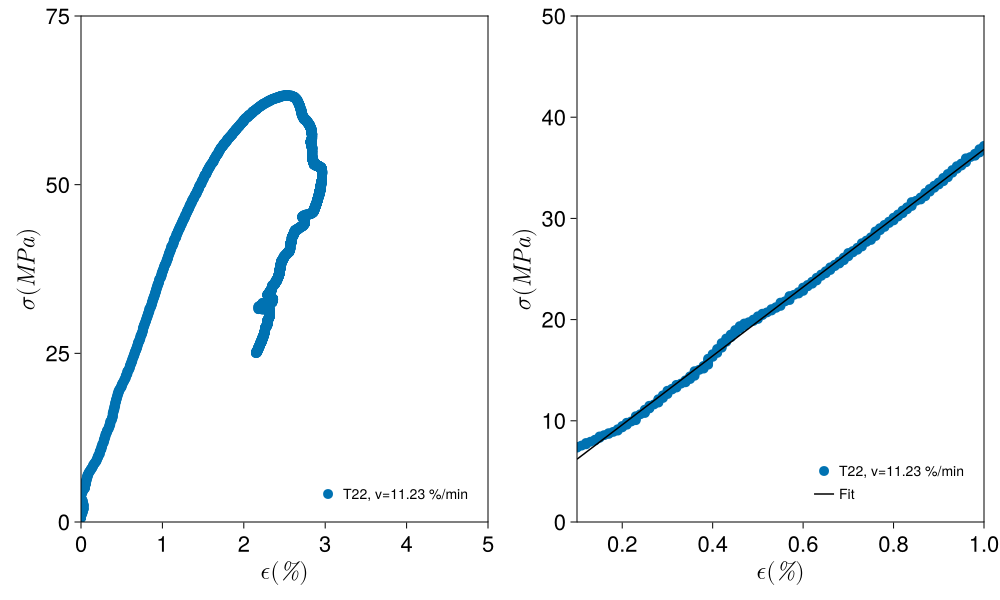

In [3055]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



DataProperties=[]
aktuelldf=[]
for i in [2]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        
        limits!(ax1_Raum, 0, 5, 0, 75)


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, 0.1, 1,0,50)

        push!(DataProperties,properties)
        push!(aktuelldf,df)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3056]:
df_DataProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298


In [3057]:
df=aktuelldf[1]

Row,Zeit,Weg,Kraft,Länge,dL_ORG,Name,Stress,Strain,Temperature
,Float64,Float64,Float64,Float64,Float64,String,Float64,Float64,Int64
1,0.02,0.01,0.1,0.0,0.0,260126-2,0.645161,0.0,22
2,0.04,0.01,0.1,0.0,0.0,260126-2,0.645161,0.0,22
3,0.06,0.01,0.1,0.0,0.0,260126-2,0.645161,0.0,22
4,0.08,0.01,0.1,0.0,0.0,260126-2,0.645161,0.0,22
5,0.1,0.02,0.11,0.0,0.0,260126-2,0.709677,0.0,22
6,0.12,0.02,0.12,0.0,0.0,260126-2,0.774194,0.0,22
7,0.14,0.02,0.12,0.0,0.0,260126-2,0.774194,0.0,22
8,0.16,0.02,0.14,0.0,0.0,260126-2,0.903226,0.0,22
9,0.18,0.02,0.14,0.0,0.0,260126-2,0.903226,0.0,22


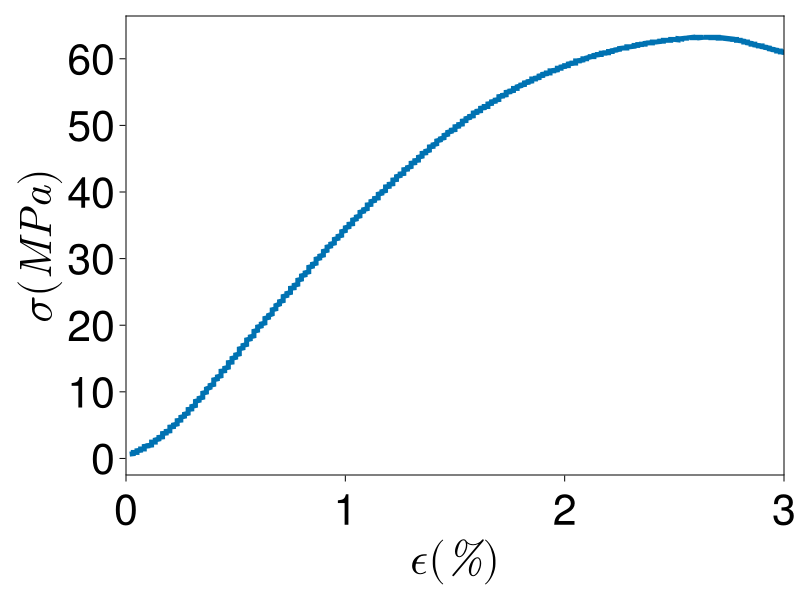

In [3058]:
Makie.lines!(axStrainRate ,(df[!,:Weg])*100/60,df[!,:Stress];
linewidth=5, 
#color = :black,
clip = true,
marker = :rect,
label = L"v= 11,23 %.$\mathrm{min^{-1}}$")


# label = "T$(T), v=$(round(df_DataProperties[1," Strain Rate[%/min]"], digits=3)) %/min"

#axislegend(axStrainRate, labelsize=font-5, framevisible=false,position = :rb)
figStrainRate


## Raum T Extended

In [3059]:

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/04 zugversuch/AP5ZK03/251006-0"
name="251006-"


"251006-"

In [3060]:
aktuellProperties=[]

Any[]

In [3061]:
## Geometrie
w=10*1e-3 # Width
t=15*1e-6 # thickness W4 from the 2nd batch
l=60*1e-3 # length between clamps
As=w*t    # stress section

1.5e-7

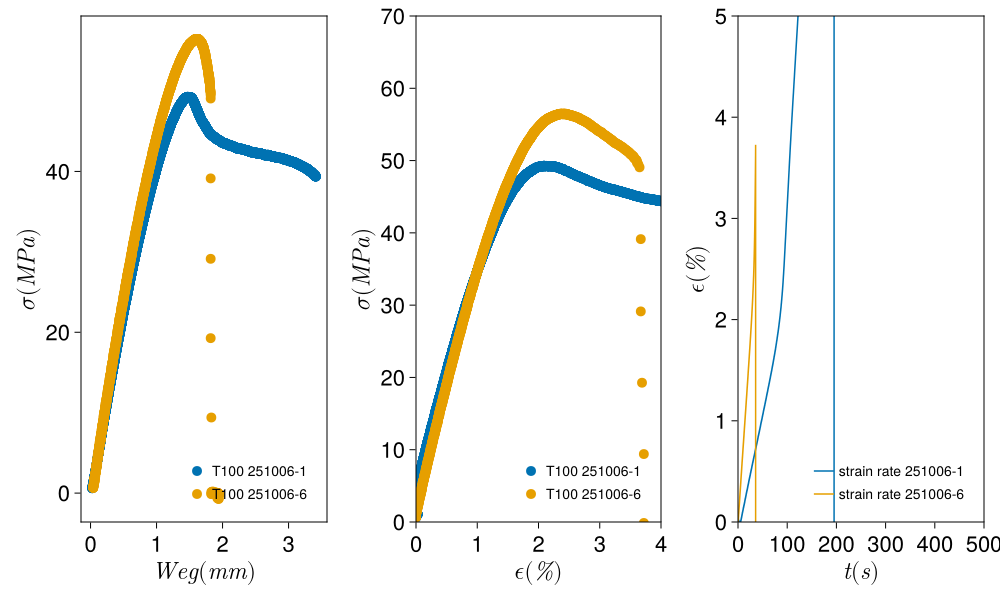

In [3062]:

#### TRaum


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [ 1 6]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)
       

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T100 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T100 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 500, 0, 5)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [3063]:
ϵ_LinearRange=[0.1 1]
ϵ_range=[0 4]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 65]
T=22
aktuellProperties=[]

Any[]

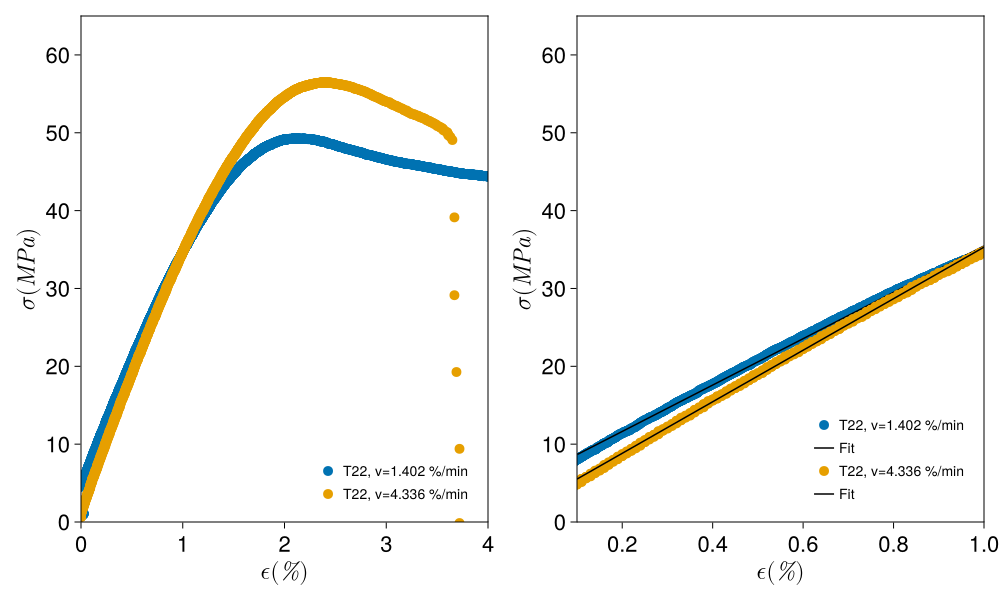

In [3064]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


aktuelldf=[]

for i in [ 1 6]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        push!(aktuelldf,df)
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3065]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,7.77176,47.7712,251006-1,2.0931,"[0.1009, 0.9999]",0.0898125,22,2.97888,49.28,34.7067,1.40248
2,14.8459,42.5532,251006-6,2.35,"[0.1, 1.0]",0.131207,22,3.31068,56.4667,34.8,4.33576


In [3066]:
aktuelldf

2-element Vector{Any}:
 5317×9 DataFrame
  Row │ Zeit     Weg      Kraft    Länge    dL_ORG   Name      Stress     Stra ⋯
      │ Float64  Float64  Float64  Float64  Float64  String    Float64    Floa ⋯
──────┼─────────────────────────────────────────────────────────────────────────
    1 │    0.22  0.02904    0.109   0.0018   0.0001  251006-1   0.726667   0.0 ⋯
    2 │    0.24  0.02941    0.11    0.003    0.0013  251006-1   0.733333   0.0
    3 │    0.26  0.02967    0.114   0.003    0.0013  251006-1   0.76       0.0
    4 │    0.28  0.03014    0.116   0.0038   0.0021  251006-1   0.773333   0.0
    5 │    0.3   0.0305     0.117   0.0038   0.0021  251006-1   0.78       0.0 ⋯
    6 │    0.32  0.03086    0.118   0.0048   0.0031  251006-1   0.786667   0.0
    7 │    0.34  0.03123    0.121   0.0048   0.0031  251006-1   0.806667   0.0
    8 │    0.36  0.03149    0.122   0.0076   0.0059  251006-1   0.813333   0.0
  ⋮   │    ⋮        ⋮        ⋮        ⋮        ⋮        ⋮          ⋮         ⋮ ⋱

In [3067]:
la=[L"v= 1,40 %.$\mathrm{min^{-1}}$" L"v= 4,33 %.$\mathrm{min^{-1}}$"  ]

1×2 Matrix{LaTeXStrings.LaTeXString}:
 L"v= 1,40 %.$\mathrm{min^{-1}}$"  L"v= 4,33 %.$\mathrm{min^{-1}}$"

In [3068]:
n=1
for i in aktuelldf
    
    Makie.lines!(axStrainRate ,(i[!,:Weg])*100/60,i[!,:Stress];
    linewidth=5,  
    #color = :black,
    clip = true,
    marker = :rect,
    label = la[n])
    n=n+1
end


In [3069]:
push!(DataProperties,aktuellProperties[1])
push!(DataProperties,aktuellProperties[2])


3-element Vector{Any}:
 Dict{String, Any}("e_max[%]" => 5.599483284541063, "δ_F/δ_B" => 39.682539682539684, "Probe" => "260126-2", "δ_B" => 2.52, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.2590609396773203, "Temperature [C]" => 22, "E[GPa] " => 3.4017543510437074, "sigmaMax" => 63.29032258064516, "sigma0_25% " => 37.16129032258065…)
 Dict{String, Any}("e_max[%]" => 7.771756230779717, "δ_F/δ_B" => 47.77124838755912, "Probe" => "251006-1", "δ_B" => 2.0931, "LinearRange [%]" => [0.1009, 0.9999], "u_E[%] " => 0.08981245572247142, "Temperature [C]" => 22, "E[GPa] " => 2.9788802819755604, "sigmaMax" => 49.28, "sigma0_25% " => 34.70666666666666…)
 Dict{String, Any}("e_max[%]" => 14.845928964637459, "δ_F/δ_B" => 42.5531914893617, "Probe" => "251006-6", "δ_B" => 2.35, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.13120712156381875, "Temperature [C]" => 22, "E[GPa] " => 3.3106796729354904, "sigmaMax" => 56.46666666666667, "sigma0_25% " => 34.8…)

In [3070]:
df_DataProperties=DataFrame(DataProperties)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
2,7.77176,47.7712,251006-1,2.0931,"[0.1009, 0.9999]",0.0898125,22,2.97888,49.28,34.7067,1.40248
3,14.8459,42.5532,251006-6,2.35,"[0.1, 1.0]",0.131207,22,3.31068,56.4667,34.8,4.33576


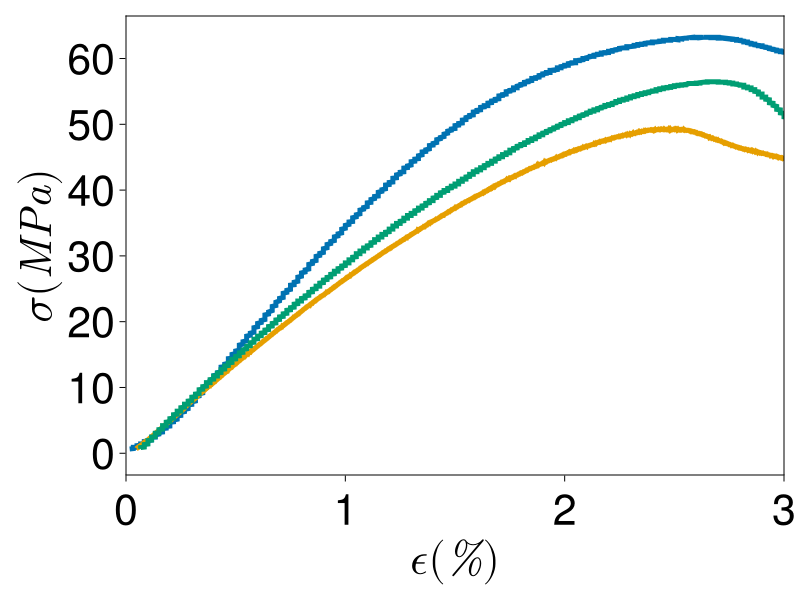

In [3071]:

figStrainRate

### Strain rate 25 o 27

In [3073]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/04 zugversuch/AP5ZK04/251103-"
name="251103-"


"251103-"

In [3074]:
aktuellProperties=[]

Any[]

In [3075]:
## Geometrie
w=10*1e-3 # Width
t=15*1e-6 # thickness W4 from the 2nd batch
l=60*1e-3 # length between clamps
As=w*t    # stress section

1.5e-7

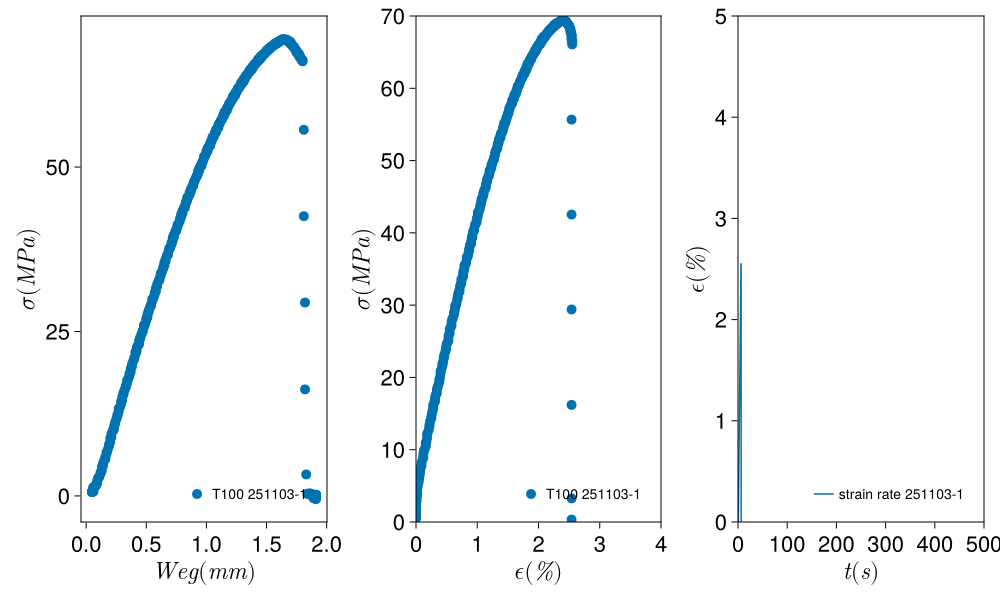

In [3076]:

#### TRaum


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [ 1]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)
       

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T100 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T100 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 500, 0, 5)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [3077]:
ϵ_LinearRange=[0.1 1]
ϵ_range=[0 4]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 65]
T=22
aktuellProperties=[]

Any[]

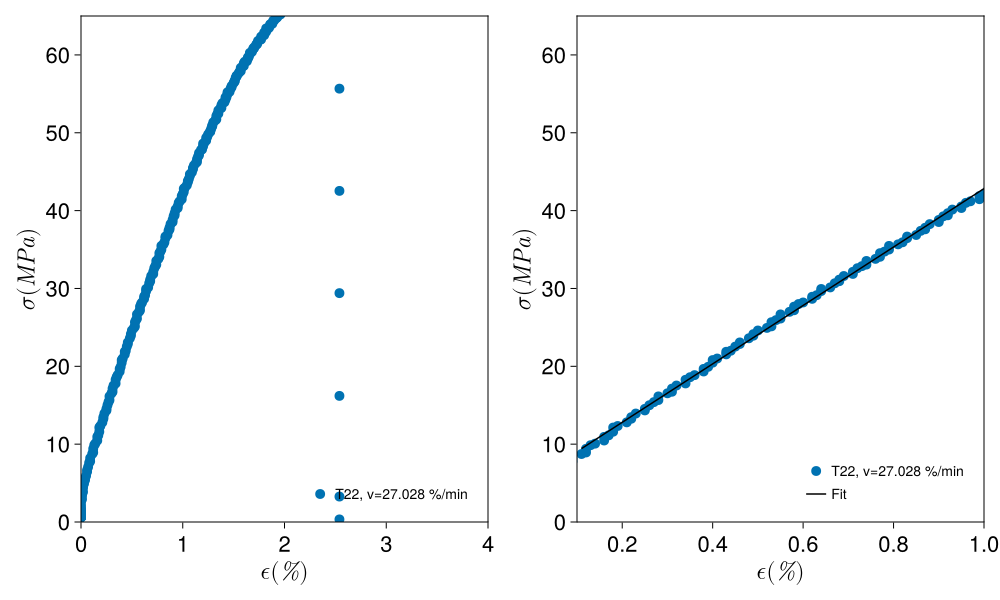

In [3078]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


aktuelldf=[]
for i in [ 1 ]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        push!(aktuelldf,df)
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3079]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,9.75169,41.841,251103-1,2.39,"[0.11, 1.0]",0.373016,22,3.75285,69.4667,42.1333,27.0283


In [3080]:
push!(DataProperties,aktuellProperties[1])


4-element Vector{Any}:
 Dict{String, Any}("e_max[%]" => 5.599483284541063, "δ_F/δ_B" => 39.682539682539684, "Probe" => "260126-2", "δ_B" => 2.52, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.2590609396773203, "Temperature [C]" => 22, "E[GPa] " => 3.4017543510437074, "sigmaMax" => 63.29032258064516, "sigma0_25% " => 37.16129032258065…)
 Dict{String, Any}("e_max[%]" => 7.771756230779717, "δ_F/δ_B" => 47.77124838755912, "Probe" => "251006-1", "δ_B" => 2.0931, "LinearRange [%]" => [0.1009, 0.9999], "u_E[%] " => 0.08981245572247142, "Temperature [C]" => 22, "E[GPa] " => 2.9788802819755604, "sigmaMax" => 49.28, "sigma0_25% " => 34.70666666666666…)
 Dict{String, Any}("e_max[%]" => 14.845928964637459, "δ_F/δ_B" => 42.5531914893617, "Probe" => "251006-6", "δ_B" => 2.35, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.13120712156381875, "Temperature [C]" => 22, "E[GPa] " => 3.3106796729354904, "sigmaMax" => 56.46666666666667, "sigma0_25% " => 34.8…)
 Dict{String, Any}("e_max[%]" => 9.75168952

In [3081]:
df_DataProperties=DataFrame(DataProperties)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
2,7.77176,47.7712,251006-1,2.0931,"[0.1009, 0.9999]",0.0898125,22,2.97888,49.28,34.7067,1.40248
3,14.8459,42.5532,251006-6,2.35,"[0.1, 1.0]",0.131207,22,3.31068,56.4667,34.8,4.33576
4,9.75169,41.841,251103-1,2.39,"[0.11, 1.0]",0.373016,22,3.75285,69.4667,42.1333,27.0283


In [3082]:
n=1
for i in aktuelldf
    
    Makie.lines!(axStrainRate ,(i[!,:Weg])*100/60,i[!,:Stress];
    linewidth=5, 
    #color = :black,
    clip = true,
    marker = :rect,
    label =L"v= 27,03 %.$\mathrm{min^{-1}}$")
    n=n+1
end

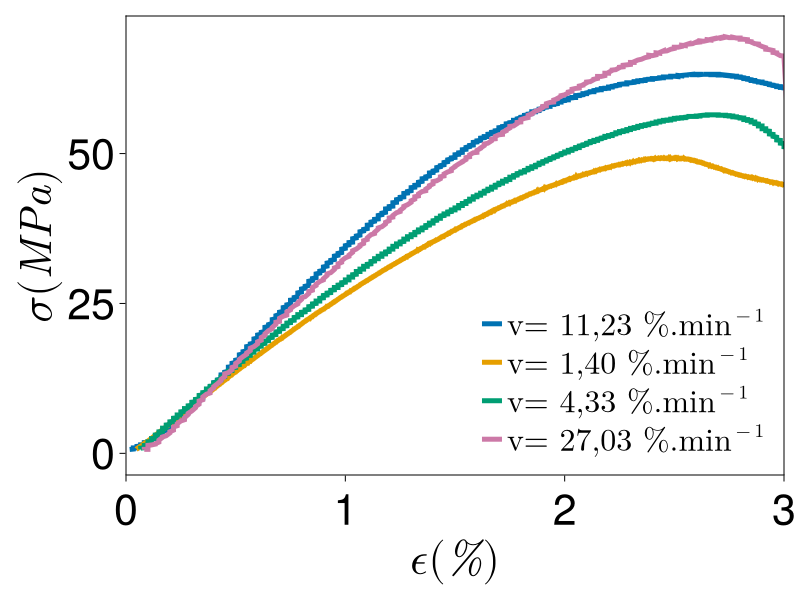

In [3083]:
axislegend(axStrainRate, labelsize=font+8, framevisible=false,position = :rb)

figStrainRate

## Temperatur 40

In [3084]:

BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [3085]:
df_260126=[]

Any[]

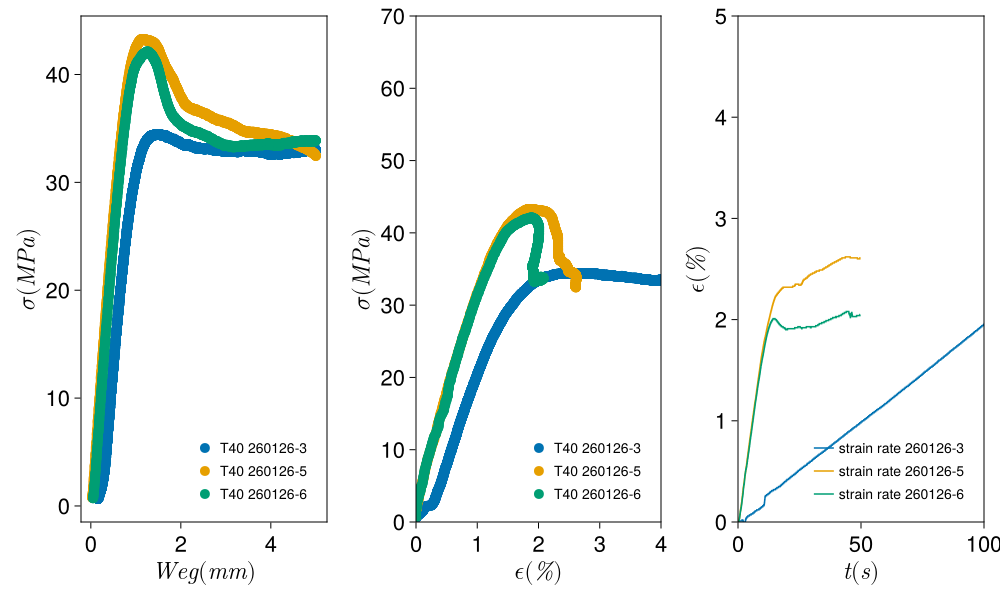

In [3086]:

#### T40


## Geometrie
w=10*1e-3 # Width
t=15.5*1e-6 # thickness W4 from the 2nd batch
l=60*1e-3 # length between clamps
As=w*t    # stress section


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [3 5 6]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T40 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T40 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 100, 0, 5)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [3087]:
ϵ_LinearRange=[0.5 1]
ϵ_range=[0 4]
t_range=[0 100] #in order to avoid wrong measurements from the camera
σ_range=[0 50]
T=40

40

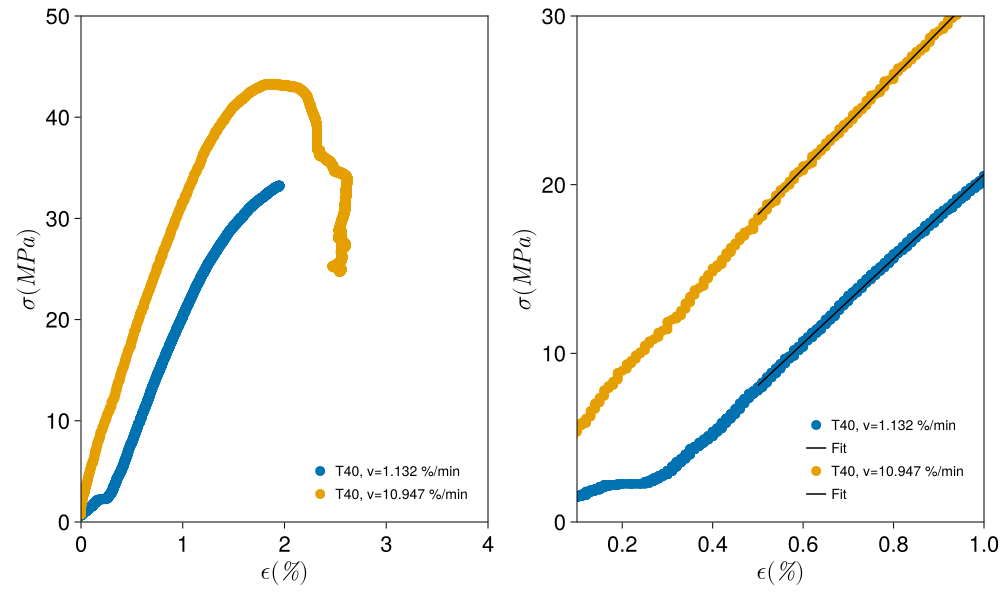

In [3088]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



for i in [3 5 ]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        
        limits!(ax1_Raum, 0, 4, 0, 50)


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, 0.1, 1,0,30)

        push!(DataProperties,properties)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3089]:
df_DataProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
2,7.77176,47.7712,251006-1,2.0931,"[0.1009, 0.9999]",0.0898125,22,2.97888,49.28,34.7067,1.40248
3,14.8459,42.5532,251006-6,2.35,"[0.1, 1.0]",0.131207,22,3.31068,56.4667,34.8,4.33576
4,9.75169,41.841,251103-1,2.39,"[0.11, 1.0]",0.373016,22,3.75285,69.4667,42.1333,27.0283
5,4.29725,51.5464,260126-3,1.94,"[0.5, 1.0]",0.108925,40,2.5055,33.2258,20.5161,1.1322
6,1.99845,54.9451,260126-5,1.82,"[0.5, 1.0]",0.27083,40,2.71908,43.2903,31.6129,10.9466


## Temperatur 50

In [3090]:

BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [3091]:
df_260126=[]

Any[]

In [3092]:
aktuellProperties=[]

Any[]

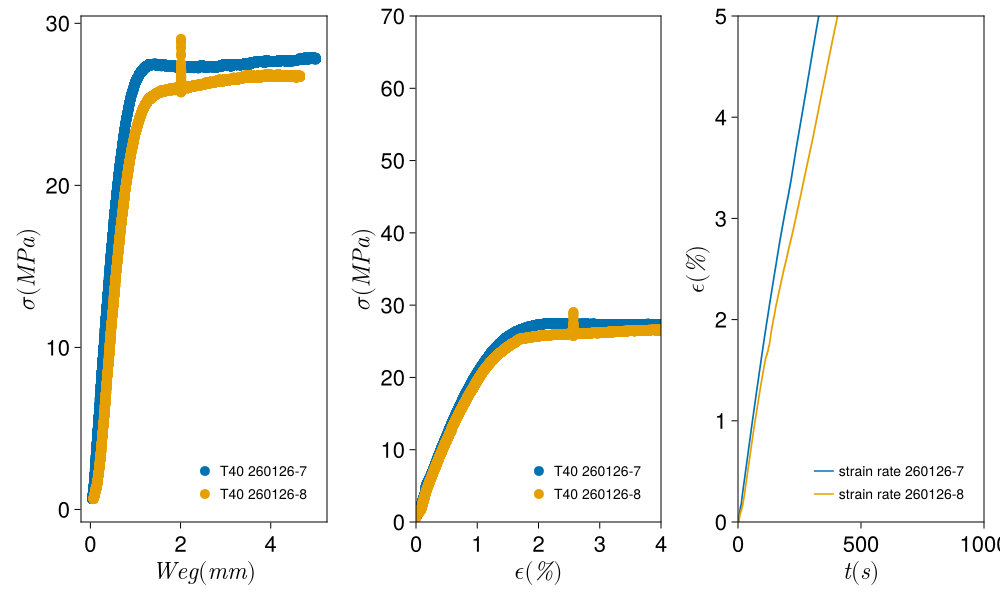

In [3093]:

#### T50

## Geometrie
w=10*1e-3 # Width
t=15.5*1e-6 # thickness W4 from the 2nd batch
l=60*1e-3 # length between clamps
As=w*t    # stress section


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [7 8]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T40 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T40 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 1000, 0, 5)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [3094]:
ϵ_LinearRange=[0.2 0.8]
ϵ_range=[0 4]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 30]
T=50
aktuellProperties=[]

Any[]

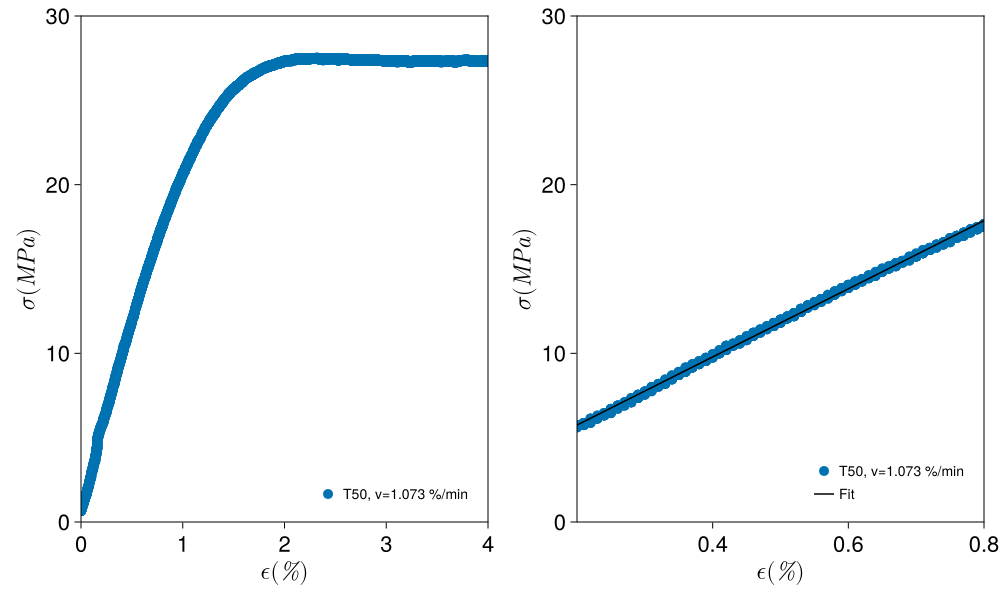

In [3095]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



for i in [7]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3096]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,4.7615,34.4828,260126-7,2.32,"[0.2, 0.8]",0.0955177,50,2.01977,27.5484,17.6774,1.07343


In [3097]:
push!(DataProperties,aktuellProperties[1])
push!(DataProperties,aktuellProperties[2])

BoundsError: BoundsError: attempt to access 1-element Vector{Any} at index [2]

In [3098]:
df_DataProperties=DataFrame(DataProperties)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
2,7.77176,47.7712,251006-1,2.0931,"[0.1009, 0.9999]",0.0898125,22,2.97888,49.28,34.7067,1.40248
3,14.8459,42.5532,251006-6,2.35,"[0.1, 1.0]",0.131207,22,3.31068,56.4667,34.8,4.33576
4,9.75169,41.841,251103-1,2.39,"[0.11, 1.0]",0.373016,22,3.75285,69.4667,42.1333,27.0283
5,4.29725,51.5464,260126-3,1.94,"[0.5, 1.0]",0.108925,40,2.5055,33.2258,20.5161,1.1322
6,1.99845,54.9451,260126-5,1.82,"[0.5, 1.0]",0.27083,40,2.71908,43.2903,31.6129,10.9466
7,4.7615,34.4828,260126-7,2.32,"[0.2, 0.8]",0.0955177,50,2.01977,27.5484,17.6774,1.07343


## Temperatur 50 Extended

In [3099]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/04 zugversuch/AP5ZK04/251103-"
name="251103-"


"251103-"

In [3100]:
aktuellProperties=[]

Any[]

In [3101]:
## Geometrie
w=10*1e-3 # Width
t=15*1e-6 # thickness W4 from the 2nd batch
l=60*1e-3 # length between clamps
As=w*t    # stress section

1.5e-7

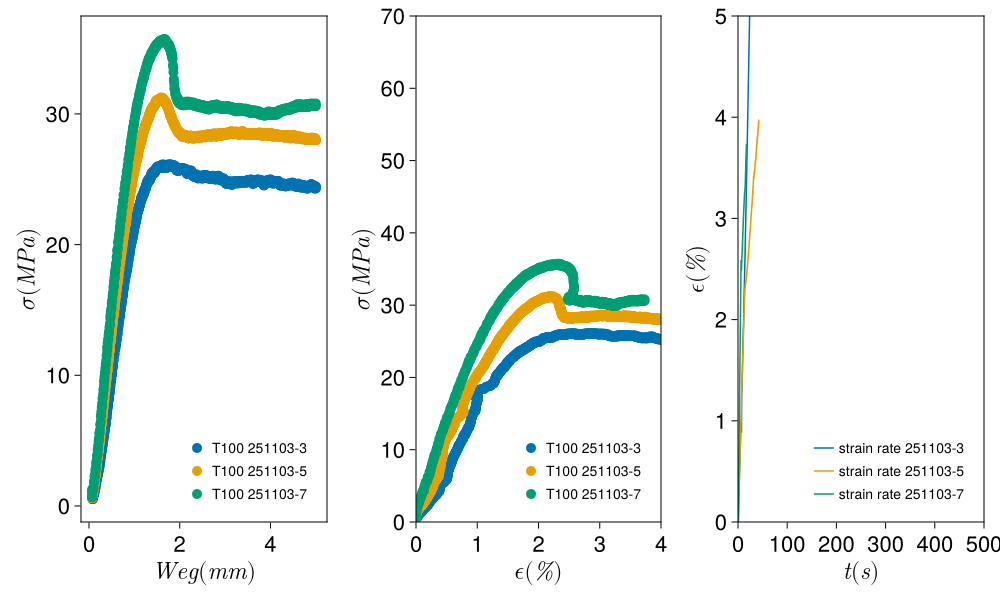

In [3102]:

#### TRaum


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [ 3 5  7]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)
       

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T100 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T100 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 500, 0, 5)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [3103]:
ϵ_LinearRange=[0.1 1]
ϵ_range=[0 4]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 50]
T=50
aktuellProperties=[]

Any[]

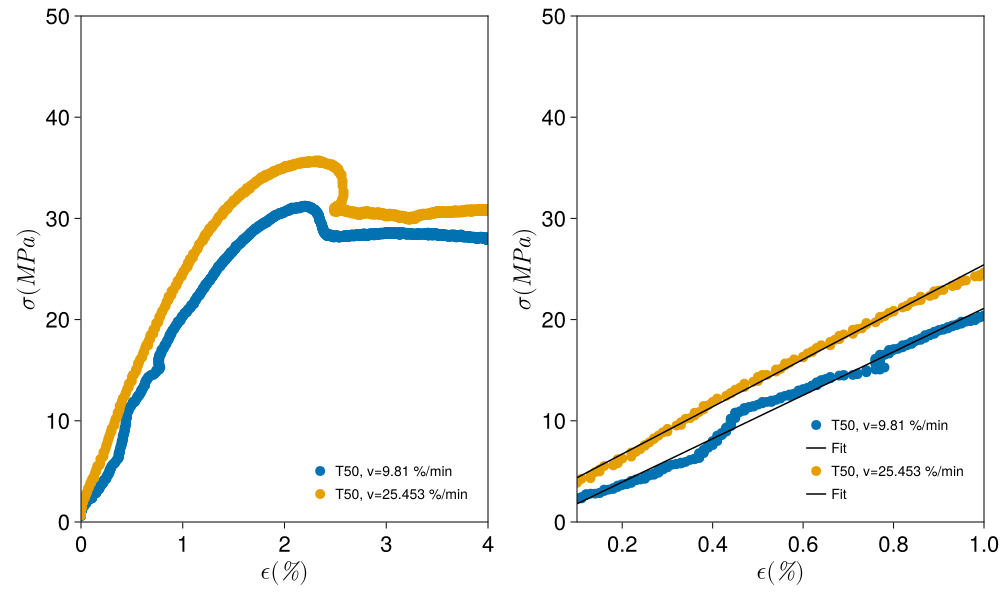

In [3104]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



for i in [ 5 7]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3105]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,19.8779,45.4545,251103-5,2.2,"[0.1, 1.0]",0.749415,50,2.14537,31.2667,20.4,9.80967
2,17.1634,43.29,251103-7,2.31,"[0.1, 1.0]",0.612399,50,2.33842,35.7333,24.6667,25.4532


In [3106]:
push!(DataProperties,aktuellProperties[1])
push!(DataProperties,aktuellProperties[2])


9-element Vector{Any}:
 Dict{String, Any}("e_max[%]" => 5.599483284541063, "δ_F/δ_B" => 39.682539682539684, "Probe" => "260126-2", "δ_B" => 2.52, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.2590609396773203, "Temperature [C]" => 22, "E[GPa] " => 3.4017543510437074, "sigmaMax" => 63.29032258064516, "sigma0_25% " => 37.16129032258065…)
 Dict{String, Any}("e_max[%]" => 7.771756230779717, "δ_F/δ_B" => 47.77124838755912, "Probe" => "251006-1", "δ_B" => 2.0931, "LinearRange [%]" => [0.1009, 0.9999], "u_E[%] " => 0.08981245572247142, "Temperature [C]" => 22, "E[GPa] " => 2.9788802819755604, "sigmaMax" => 49.28, "sigma0_25% " => 34.70666666666666…)
 Dict{String, Any}("e_max[%]" => 14.845928964637459, "δ_F/δ_B" => 42.5531914893617, "Probe" => "251006-6", "δ_B" => 2.35, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.13120712156381875, "Temperature [C]" => 22, "E[GPa] " => 3.3106796729354904, "sigmaMax" => 56.46666666666667, "sigma0_25% " => 34.8…)
 Dict{String, Any}("e_max[%]" => 9.75168952

In [3107]:
df_DataProperties=DataFrame(DataProperties)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
2,7.77176,47.7712,251006-1,2.0931,"[0.1009, 0.9999]",0.0898125,22,2.97888,49.28,34.7067,1.40248
3,14.8459,42.5532,251006-6,2.35,"[0.1, 1.0]",0.131207,22,3.31068,56.4667,34.8,4.33576
4,9.75169,41.841,251103-1,2.39,"[0.11, 1.0]",0.373016,22,3.75285,69.4667,42.1333,27.0283
5,4.29725,51.5464,260126-3,1.94,"[0.5, 1.0]",0.108925,40,2.5055,33.2258,20.5161,1.1322
6,1.99845,54.9451,260126-5,1.82,"[0.5, 1.0]",0.27083,40,2.71908,43.2903,31.6129,10.9466
7,4.7615,34.4828,260126-7,2.32,"[0.2, 0.8]",0.0955177,50,2.01977,27.5484,17.6774,1.07343
8,19.8779,45.4545,251103-5,2.2,"[0.1, 1.0]",0.749415,50,2.14537,31.2667,20.4,9.80967
9,17.1634,43.29,251103-7,2.31,"[0.1, 1.0]",0.612399,50,2.33842,35.7333,24.6667,25.4532


## Temperatur 60

In [3108]:
BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [3109]:
df_260126=[]

Any[]

In [3110]:
aktuellProperties=[]

Any[]

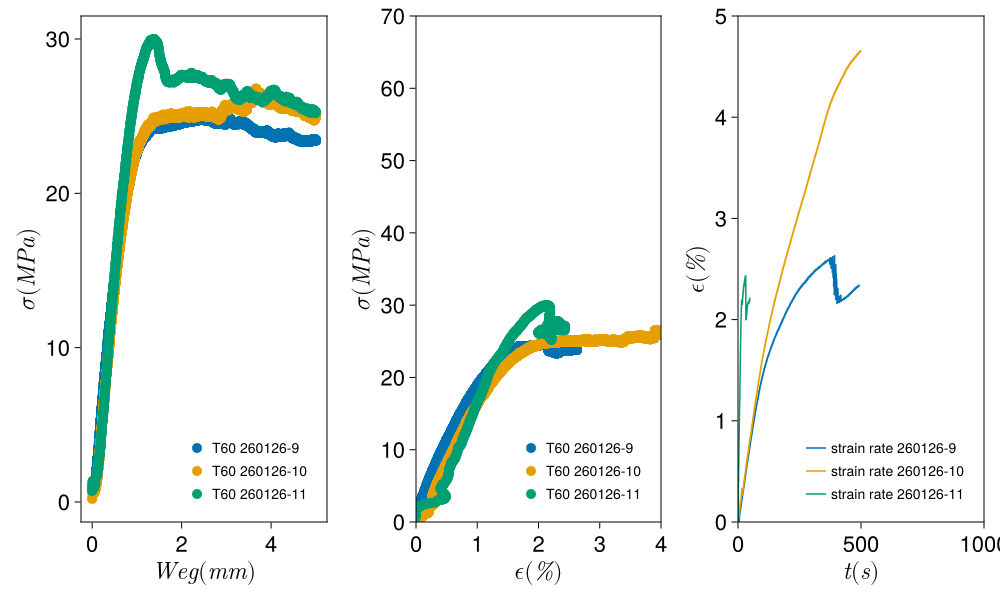

In [3111]:

#### T60


## Geometrie
w=10*1e-3 # Width
t=15.5*1e-6 # thickness W4 from the 2nd batch
l=60*1e-3 # length between clamps
As=w*t    # stress section


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [ 9 10 11]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T60 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T60 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 1000, 0, 5)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [3112]:
ϵ_LinearRange=[0.5 1]
ϵ_range=[0 2]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 35]
T=60
aktuellProperties=[]

Any[]

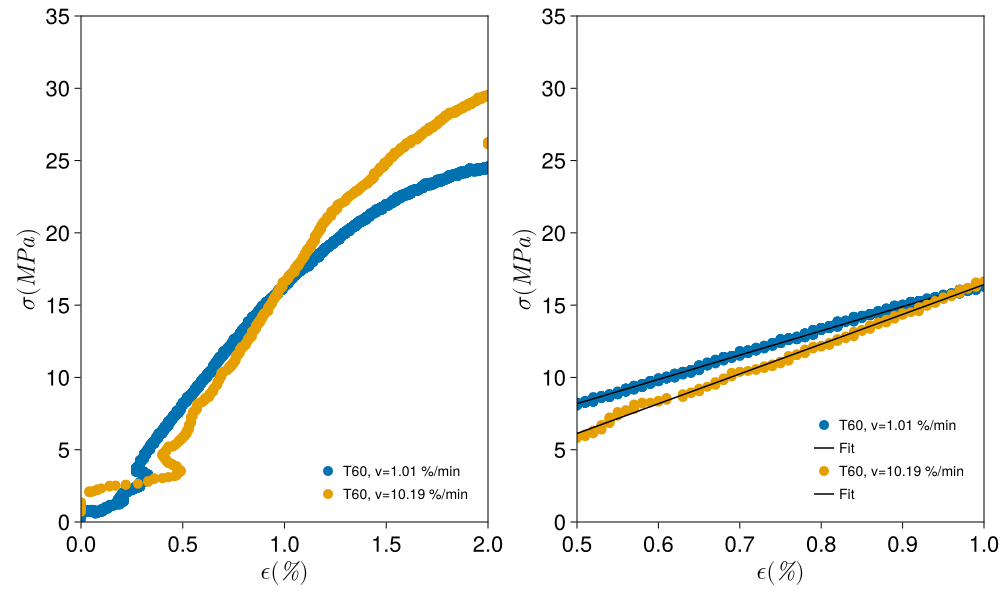

In [3113]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



for i in [10 11]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3114]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,2.46872,50.0,260126-10,2.0,"[0.5, 1.0]",0.128125,60,1.678,24.5806,16.3871,1.00988
2,6.63639,50.0,260126-11,2.0,"[0.5, 1.0]",0.488149,60,2.05936,29.5484,16.6452,10.1898


In [3115]:
push!(DataProperties,aktuellProperties[1])
push!(DataProperties,aktuellProperties[2])
push!(DataProperties,aktuellProperties[3])

BoundsError: BoundsError: attempt to access 2-element Vector{Any} at index [3]

In [3116]:
df_DataProperties=DataFrame(DataProperties)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
2,7.77176,47.7712,251006-1,2.0931,"[0.1009, 0.9999]",0.0898125,22,2.97888,49.28,34.7067,1.40248
3,14.8459,42.5532,251006-6,2.35,"[0.1, 1.0]",0.131207,22,3.31068,56.4667,34.8,4.33576
4,9.75169,41.841,251103-1,2.39,"[0.11, 1.0]",0.373016,22,3.75285,69.4667,42.1333,27.0283
5,4.29725,51.5464,260126-3,1.94,"[0.5, 1.0]",0.108925,40,2.5055,33.2258,20.5161,1.1322
6,1.99845,54.9451,260126-5,1.82,"[0.5, 1.0]",0.27083,40,2.71908,43.2903,31.6129,10.9466
7,4.7615,34.4828,260126-7,2.32,"[0.2, 0.8]",0.0955177,50,2.01977,27.5484,17.6774,1.07343
8,19.8779,45.4545,251103-5,2.2,"[0.1, 1.0]",0.749415,50,2.14537,31.2667,20.4,9.80967
9,17.1634,43.29,251103-7,2.31,"[0.1, 1.0]",0.612399,50,2.33842,35.7333,24.6667,25.4532


## Temperatur 80

In [3117]:

BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [3118]:
df_260126=[]

Any[]

In [3119]:
aktuellProperties=[]

Any[]

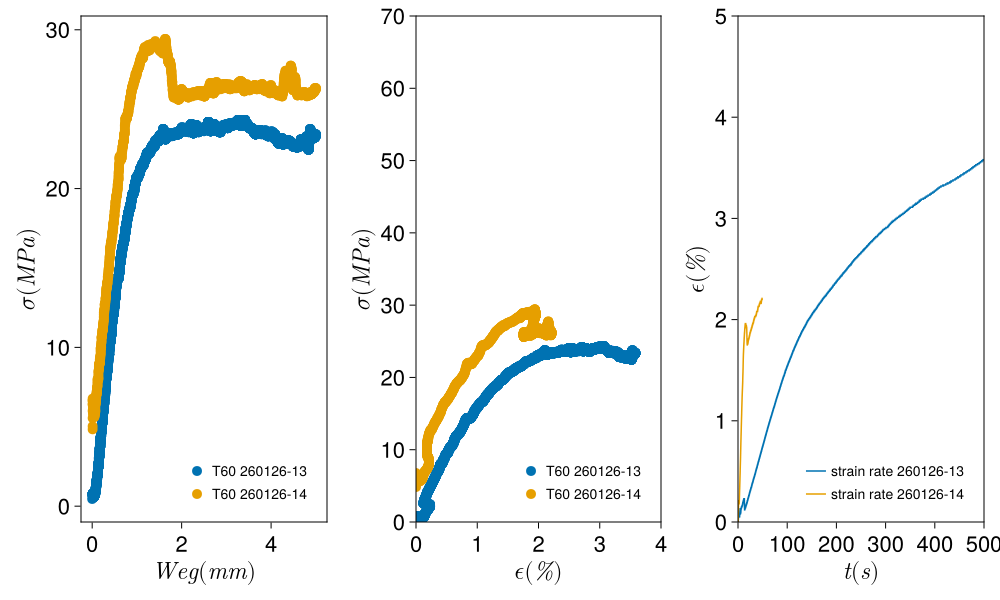

In [3120]:

#### T80

## Geometrie
w=10*1e-3 # Width
t=15.5*1e-6 # thickness W4 from the 2nd batch
l=60*1e-3 # length between clamps
As=w*t    # stress section


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [  13 14]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)
       

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T60 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T60 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 500, 0, 5)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [3121]:
ϵ_LinearRange=[0.5 1]
ϵ_range=[0 2]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 35]
T=80
aktuellProperties=[]

Any[]

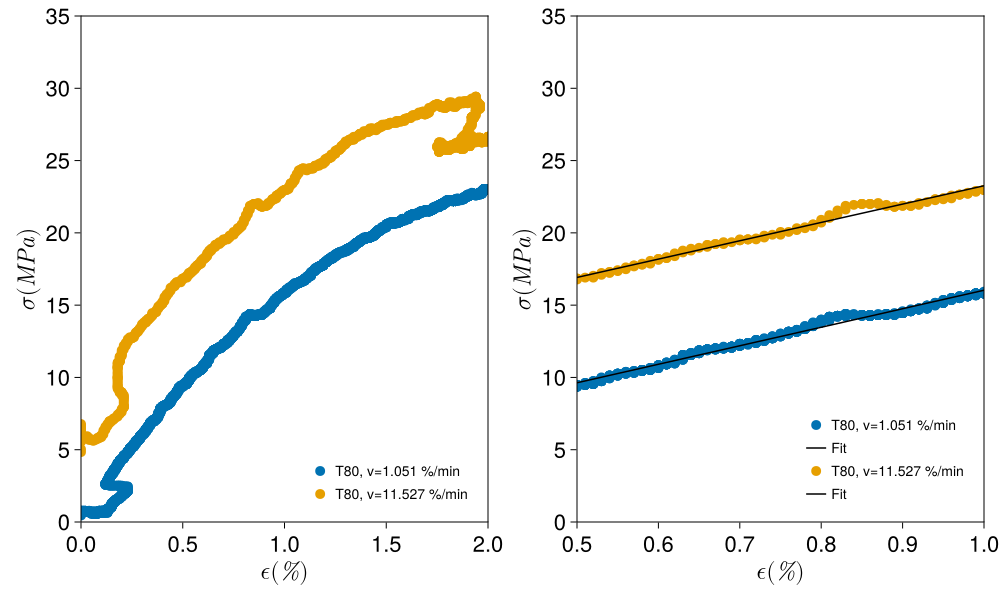

In [3122]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



for i in [ 13 14]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3123]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,3.53694,50.5051,260126-13,1.98,"[0.5, 1.0]",0.301246,80,1.28044,23.0323,15.9355,1.0511
2,1.62015,51.5464,260126-14,1.94,"[0.5, 1.0]",1.15313,80,1.26804,29.4194,22.9677,11.5265


In [3124]:
push!(DataProperties,aktuellProperties[1])
push!(DataProperties,aktuellProperties[2])


13-element Vector{Any}:
 Dict{String, Any}("e_max[%]" => 5.599483284541063, "δ_F/δ_B" => 39.682539682539684, "Probe" => "260126-2", "δ_B" => 2.52, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.2590609396773203, "Temperature [C]" => 22, "E[GPa] " => 3.4017543510437074, "sigmaMax" => 63.29032258064516, "sigma0_25% " => 37.16129032258065…)
 Dict{String, Any}("e_max[%]" => 7.771756230779717, "δ_F/δ_B" => 47.77124838755912, "Probe" => "251006-1", "δ_B" => 2.0931, "LinearRange [%]" => [0.1009, 0.9999], "u_E[%] " => 0.08981245572247142, "Temperature [C]" => 22, "E[GPa] " => 2.9788802819755604, "sigmaMax" => 49.28, "sigma0_25% " => 34.70666666666666…)
 Dict{String, Any}("e_max[%]" => 14.845928964637459, "δ_F/δ_B" => 42.5531914893617, "Probe" => "251006-6", "δ_B" => 2.35, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.13120712156381875, "Temperature [C]" => 22, "E[GPa] " => 3.3106796729354904, "sigmaMax" => 56.46666666666667, "sigma0_25% " => 34.8…)
 Dict{String, Any}("e_max[%]" => 9.7516895

In [3125]:
df_DataProperties=DataFrame(DataProperties)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
2,7.77176,47.7712,251006-1,2.0931,"[0.1009, 0.9999]",0.0898125,22,2.97888,49.28,34.7067,1.40248
3,14.8459,42.5532,251006-6,2.35,"[0.1, 1.0]",0.131207,22,3.31068,56.4667,34.8,4.33576
4,9.75169,41.841,251103-1,2.39,"[0.11, 1.0]",0.373016,22,3.75285,69.4667,42.1333,27.0283
5,4.29725,51.5464,260126-3,1.94,"[0.5, 1.0]",0.108925,40,2.5055,33.2258,20.5161,1.1322
6,1.99845,54.9451,260126-5,1.82,"[0.5, 1.0]",0.27083,40,2.71908,43.2903,31.6129,10.9466
7,4.7615,34.4828,260126-7,2.32,"[0.2, 0.8]",0.0955177,50,2.01977,27.5484,17.6774,1.07343
8,19.8779,45.4545,251103-5,2.2,"[0.1, 1.0]",0.749415,50,2.14537,31.2667,20.4,9.80967
9,17.1634,43.29,251103-7,2.31,"[0.1, 1.0]",0.612399,50,2.33842,35.7333,24.6667,25.4532


## Temperatur 100

In [3126]:
BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [3127]:
df_260126=[]

Any[]

In [3128]:
aktuellProperties=[]

Any[]

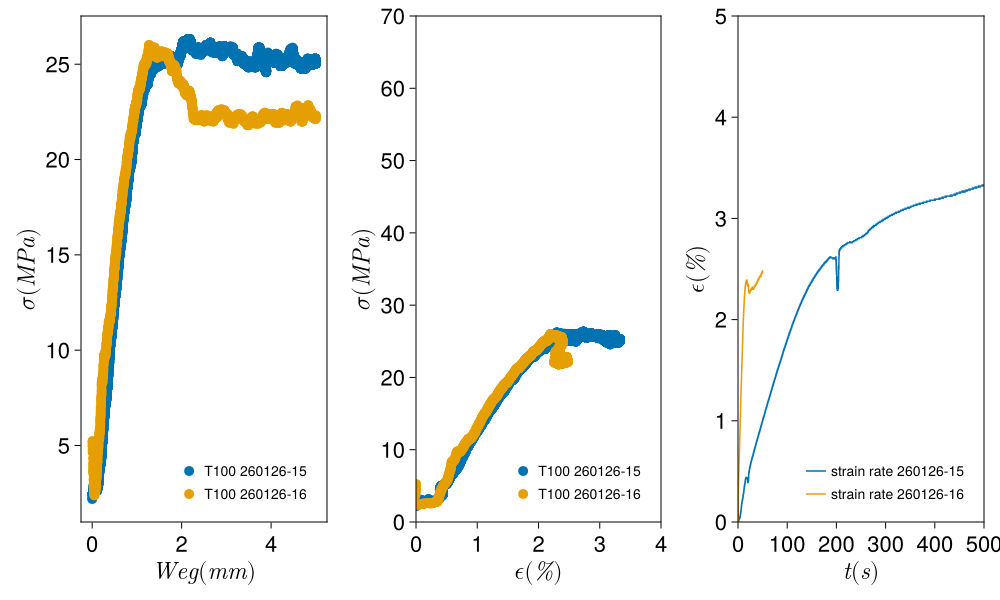

In [3129]:

#### T100

## Geometrie
w=10*1e-3 # Width
t=15.5*1e-6 # thickness W4 from the 2nd batch
l=60*1e-3 # length between clamps
As=w*t    # stress section


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [15 16]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)
       

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T100 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T100 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 500, 0, 5)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [3130]:
ϵ_LinearRange=[0.8 1.5]
ϵ_range=[0 2]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 35]
T=100
aktuellProperties=[]

Any[]

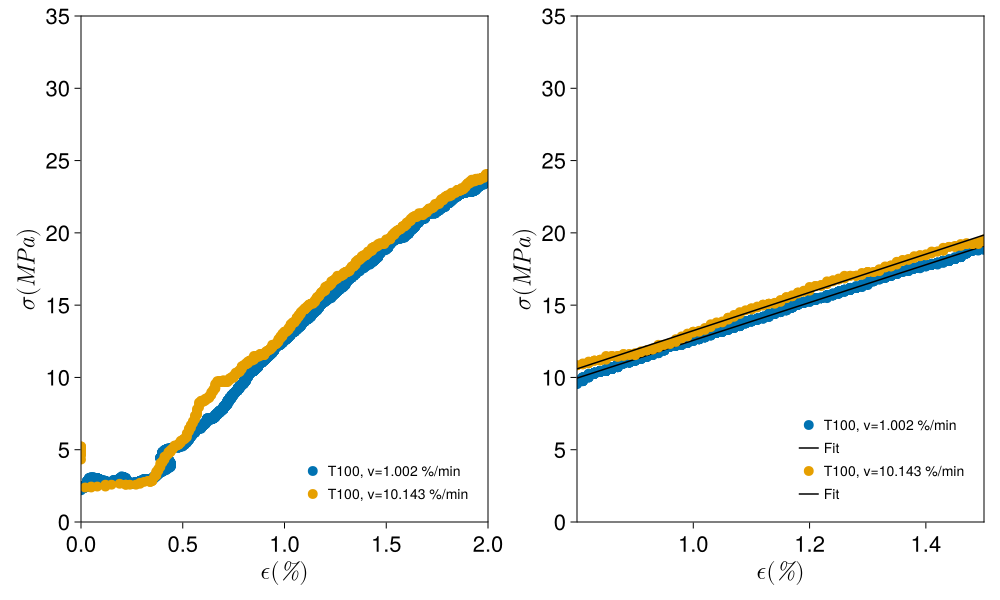

In [3131]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



for i in [ 15 16]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3132]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,4.21749,75.3769,260126-15,1.99,"[0.8, 1.5]",0.0862335,100,1.30698,23.871,19.0323,1.00169
2,3.16826,75.3769,260126-16,1.99,"[0.8, 1.5]",0.505364,100,1.3225,24.0645,19.5484,10.1427


In [3133]:
push!(DataProperties,aktuellProperties[1])
push!(DataProperties,aktuellProperties[2])


15-element Vector{Any}:
 Dict{String, Any}("e_max[%]" => 5.599483284541063, "δ_F/δ_B" => 39.682539682539684, "Probe" => "260126-2", "δ_B" => 2.52, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.2590609396773203, "Temperature [C]" => 22, "E[GPa] " => 3.4017543510437074, "sigmaMax" => 63.29032258064516, "sigma0_25% " => 37.16129032258065…)
 Dict{String, Any}("e_max[%]" => 7.771756230779717, "δ_F/δ_B" => 47.77124838755912, "Probe" => "251006-1", "δ_B" => 2.0931, "LinearRange [%]" => [0.1009, 0.9999], "u_E[%] " => 0.08981245572247142, "Temperature [C]" => 22, "E[GPa] " => 2.9788802819755604, "sigmaMax" => 49.28, "sigma0_25% " => 34.70666666666666…)
 Dict{String, Any}("e_max[%]" => 14.845928964637459, "δ_F/δ_B" => 42.5531914893617, "Probe" => "251006-6", "δ_B" => 2.35, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.13120712156381875, "Temperature [C]" => 22, "E[GPa] " => 3.3106796729354904, "sigmaMax" => 56.46666666666667, "sigma0_25% " => 34.8…)
 Dict{String, Any}("e_max[%]" => 9.7516895

In [3134]:
df_DataProperties=DataFrame(DataProperties)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
2,7.77176,47.7712,251006-1,2.0931,"[0.1009, 0.9999]",0.0898125,22,2.97888,49.28,34.7067,1.40248
3,14.8459,42.5532,251006-6,2.35,"[0.1, 1.0]",0.131207,22,3.31068,56.4667,34.8,4.33576
4,9.75169,41.841,251103-1,2.39,"[0.11, 1.0]",0.373016,22,3.75285,69.4667,42.1333,27.0283
5,4.29725,51.5464,260126-3,1.94,"[0.5, 1.0]",0.108925,40,2.5055,33.2258,20.5161,1.1322
6,1.99845,54.9451,260126-5,1.82,"[0.5, 1.0]",0.27083,40,2.71908,43.2903,31.6129,10.9466
7,4.7615,34.4828,260126-7,2.32,"[0.2, 0.8]",0.0955177,50,2.01977,27.5484,17.6774,1.07343
8,19.8779,45.4545,251103-5,2.2,"[0.1, 1.0]",0.749415,50,2.14537,31.2667,20.4,9.80967
9,17.1634,43.29,251103-7,2.31,"[0.1, 1.0]",0.612399,50,2.33842,35.7333,24.6667,25.4532


## Temperatur 100 extended

In [3135]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/04 zugversuch/AP5ZK04/251103-"
name="251103-"


"251103-"

In [3136]:
aktuellProperties=[]

Any[]

In [3137]:
## Geometrie
w=10*1e-3 # Width
t=15*1e-6 # thickness W4 from the 2nd batch
l=60*1e-3 # length between clamps
As=w*t    # stress section

1.5e-7

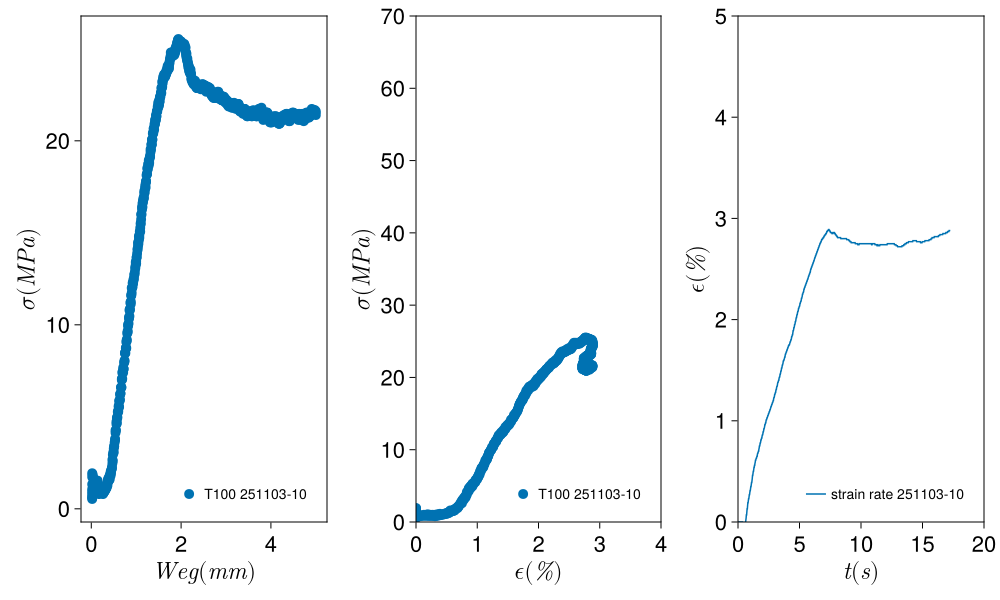

In [3138]:

#### TRaum


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [ 10]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)
       

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T100 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T100 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 20, 0, 5)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [3139]:
ϵ_LinearRange=[1 1.5]
ϵ_range=[0 4]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 35]
T=100
aktuellProperties=[]

Any[]

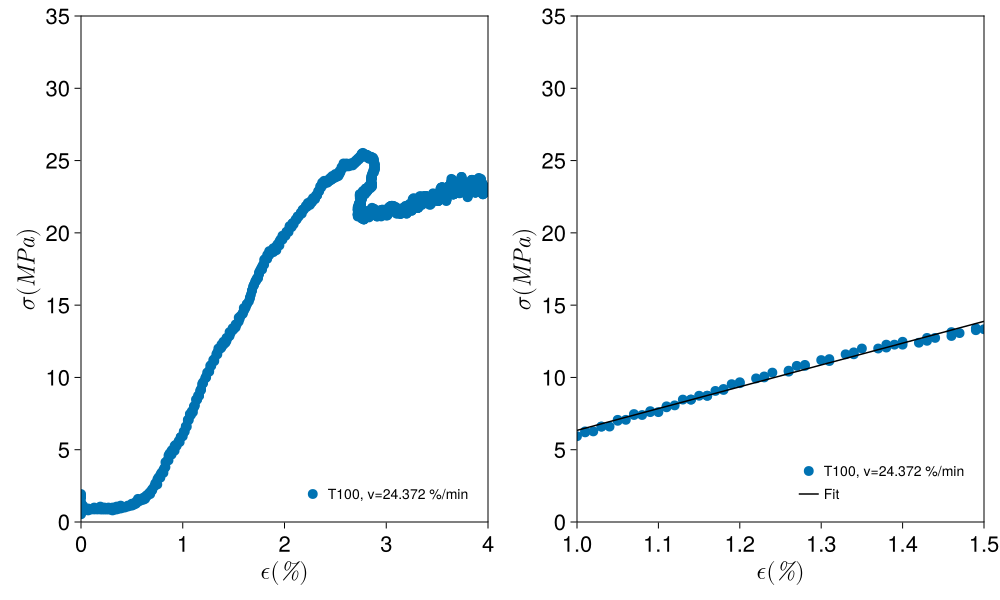

In [3140]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



for i in [10]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3141]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,6.83082,54.1516,251103-10,2.77,"[1.0, 1.5]",1.36335,100,1.50822,25.5333,13.4,24.3721


In [3142]:
push!(DataProperties,aktuellProperties[1])


16-element Vector{Any}:
 Dict{String, Any}("e_max[%]" => 5.599483284541063, "δ_F/δ_B" => 39.682539682539684, "Probe" => "260126-2", "δ_B" => 2.52, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.2590609396773203, "Temperature [C]" => 22, "E[GPa] " => 3.4017543510437074, "sigmaMax" => 63.29032258064516, "sigma0_25% " => 37.16129032258065…)
 Dict{String, Any}("e_max[%]" => 7.771756230779717, "δ_F/δ_B" => 47.77124838755912, "Probe" => "251006-1", "δ_B" => 2.0931, "LinearRange [%]" => [0.1009, 0.9999], "u_E[%] " => 0.08981245572247142, "Temperature [C]" => 22, "E[GPa] " => 2.9788802819755604, "sigmaMax" => 49.28, "sigma0_25% " => 34.70666666666666…)
 Dict{String, Any}("e_max[%]" => 14.845928964637459, "δ_F/δ_B" => 42.5531914893617, "Probe" => "251006-6", "δ_B" => 2.35, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.13120712156381875, "Temperature [C]" => 22, "E[GPa] " => 3.3106796729354904, "sigmaMax" => 56.46666666666667, "sigma0_25% " => 34.8…)
 Dict{String, Any}("e_max[%]" => 9.7516895

In [3143]:
df_DataProperties=DataFrame(DataProperties)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
2,7.77176,47.7712,251006-1,2.0931,"[0.1009, 0.9999]",0.0898125,22,2.97888,49.28,34.7067,1.40248
3,14.8459,42.5532,251006-6,2.35,"[0.1, 1.0]",0.131207,22,3.31068,56.4667,34.8,4.33576
4,9.75169,41.841,251103-1,2.39,"[0.11, 1.0]",0.373016,22,3.75285,69.4667,42.1333,27.0283
5,4.29725,51.5464,260126-3,1.94,"[0.5, 1.0]",0.108925,40,2.5055,33.2258,20.5161,1.1322
6,1.99845,54.9451,260126-5,1.82,"[0.5, 1.0]",0.27083,40,2.71908,43.2903,31.6129,10.9466
7,4.7615,34.4828,260126-7,2.32,"[0.2, 0.8]",0.0955177,50,2.01977,27.5484,17.6774,1.07343
8,19.8779,45.4545,251103-5,2.2,"[0.1, 1.0]",0.749415,50,2.14537,31.2667,20.4,9.80967
9,17.1634,43.29,251103-7,2.31,"[0.1, 1.0]",0.612399,50,2.33842,35.7333,24.6667,25.4532


## Plots für den Bericht

In [3200]:
figParylene = Figure(resolution = (1000, 600));

font=45
axParylene = Axis(figParylene[1,1],
    xlabel = L"T (°C)",
    ylabel = L"E (GPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false,
    #limits = (nothing,(0, 75))
    )


Axis with 0 plots:


In [3201]:
df_1=TIRA.filter_range(df_DataProperties," Strain Rate[%/min]",0,2)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,7.77176,47.7712,251006-1,2.0931,"[0.1009, 0.9999]",0.0898125,22,2.97888,49.28,34.7067,1.40248
2,4.29725,51.5464,260126-3,1.94,"[0.5, 1.0]",0.108925,40,2.5055,33.2258,20.5161,1.1322
3,4.7615,34.4828,260126-7,2.32,"[0.2, 0.8]",0.0955177,50,2.01977,27.5484,17.6774,1.07343
4,2.46872,50.0,260126-10,2.0,"[0.5, 1.0]",0.128125,60,1.678,24.5806,16.3871,1.00988
5,3.53694,50.5051,260126-13,1.98,"[0.5, 1.0]",0.301246,80,1.28044,23.0323,15.9355,1.0511
6,4.21749,75.3769,260126-15,1.99,"[0.8, 1.5]",0.0862335,100,1.30698,23.871,19.0323,1.00169
7,4.29725,51.5464,260126-3,1.94,"[0.5, 1.0]",0.108925,40,2.5055,33.2258,20.5161,1.1322


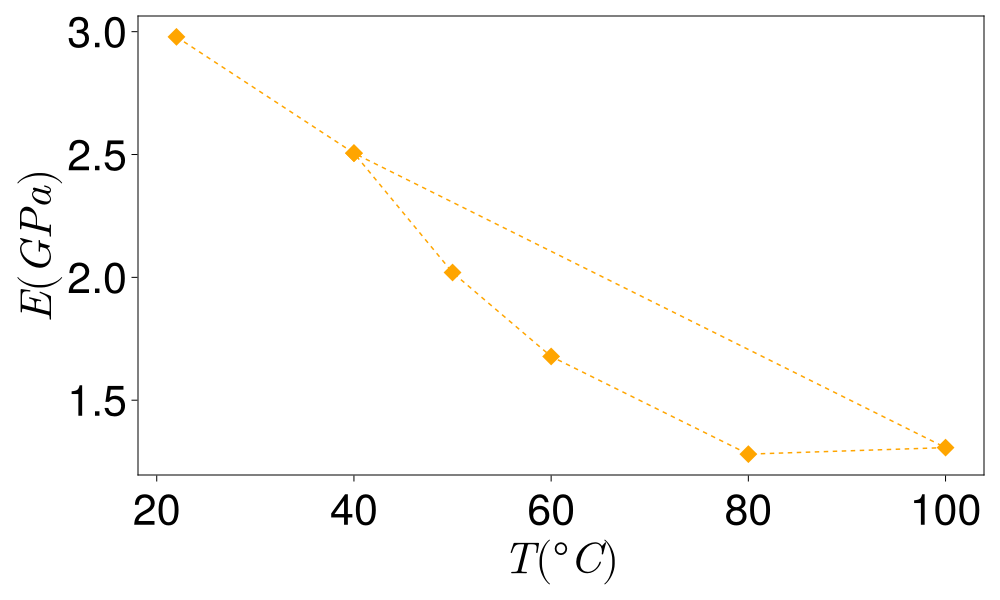

In [3202]:
    Makie.lines!(axParylene ,df_1."Temperature [C]",df_1."E[GPa] ";
    color = :orange,
    linestyle = :dash)

    
    Makie.scatter!(axParylene ,df_1."Temperature [C]",df_1."E[GPa] ";
     markersize=20, 
     label =L"v= 1 %.$\mathrm{min^{-1}}$",
     color = :orange,
     clip = true,
     marker = :diamond)
     #axislegend(axParylene, labelsize=font-10, framevisible=false,position = :rt)
     figParylene

In [3203]:
df_2=TIRA.filter_range(df_DataProperties," Strain Rate[%/min]",8,12)



Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
2,1.99845,54.9451,260126-5,1.82,"[0.5, 1.0]",0.27083,40,2.71908,43.2903,31.6129,10.9466
3,19.8779,45.4545,251103-5,2.2,"[0.1, 1.0]",0.749415,50,2.14537,31.2667,20.4,9.80967
4,6.63639,50.0,260126-11,2.0,"[0.5, 1.0]",0.488149,60,2.05936,29.5484,16.6452,10.1898
5,1.62015,51.5464,260126-14,1.94,"[0.5, 1.0]",1.15313,80,1.26804,29.4194,22.9677,11.5265
6,3.16826,75.3769,260126-16,1.99,"[0.8, 1.5]",0.505364,100,1.3225,24.0645,19.5484,10.1427


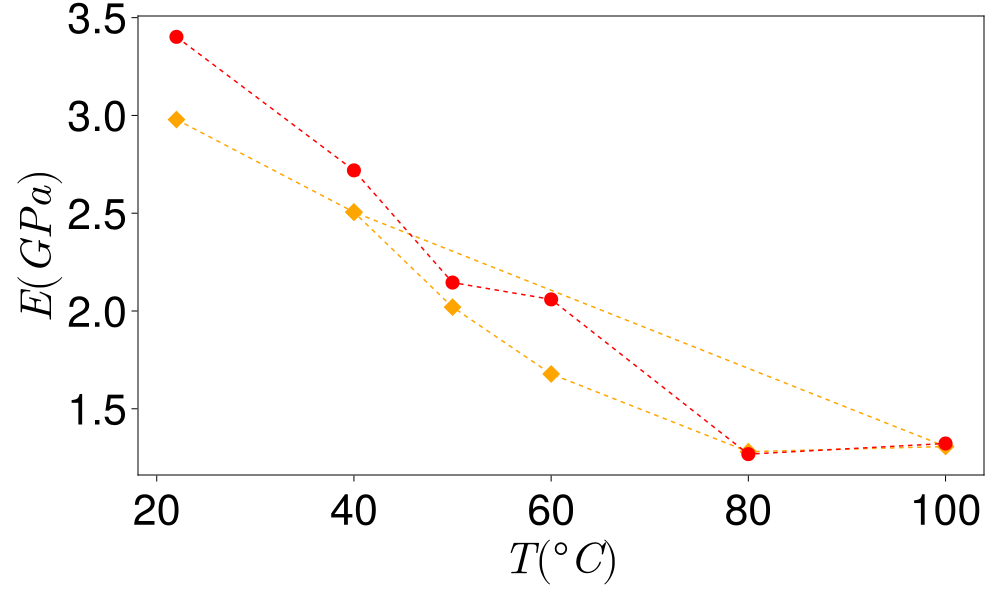

In [3204]:
    Makie.lines!(axParylene ,df_2."Temperature [C]",df_2."E[GPa] ";
    color = :red,
    linestyle = :dash)


    Makie.scatter!(axParylene ,df_2."Temperature [C]",df_2."E[GPa] ";
     markersize=20, 
     label = L"v= 10 %.$\mathrm{min^{-1}}$",
     color = :red,
     clip = true,
     marker = :circle)
     #axislegend(axParylene, labelsize=font-10, framevisible=false,position = :rt)
     figParylene

In [3205]:
df_3=TIRA.filter_range(df_DataProperties," Strain Rate[%/min]",20,28)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,9.75169,41.841,251103-1,2.39,"[0.11, 1.0]",0.373016,22,3.75285,69.4667,42.1333,27.0283
2,17.1634,43.29,251103-7,2.31,"[0.1, 1.0]",0.612399,50,2.33842,35.7333,24.6667,25.4532
3,6.83082,54.1516,251103-10,2.77,"[1.0, 1.5]",1.36335,100,1.50822,25.5333,13.4,24.3721


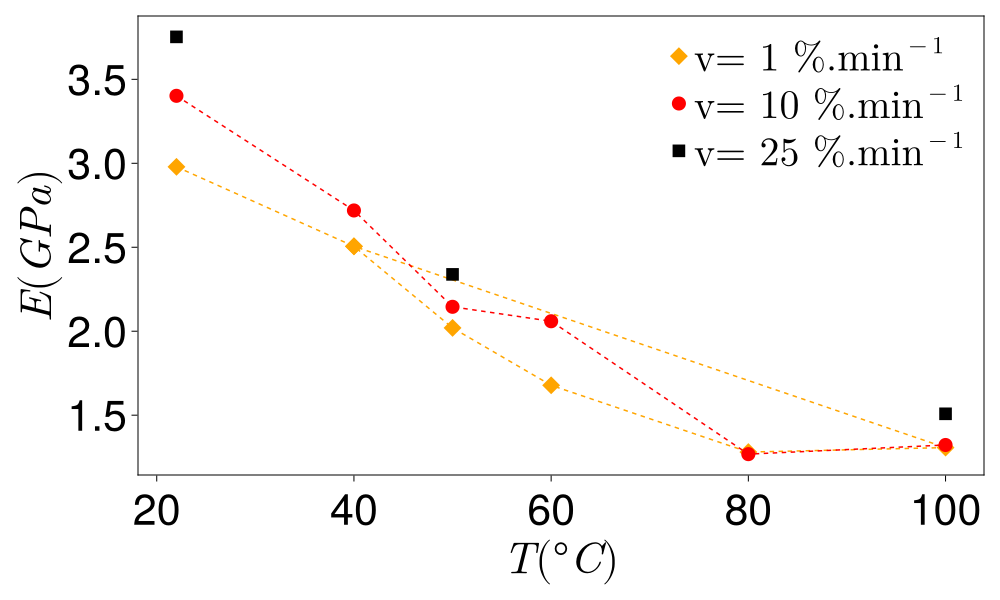

In [3206]:
    
    

    #Makie.lines!(axParylene ,df_3."Temperature [C]",df_3."E[GPa] ";
    #color = :black,
    #linestyle = :dash)

    Makie.scatter!(axParylene ,df_3."Temperature [C]",df_3."E[GPa] ";
     markersize=20, 
     label =  L"v= 25 %.$\mathrm{min^{-1}}$",
     color = :black,
     clip = true,
     marker = :rect)
     axislegend(axParylene, labelsize=font-5, framevisible=false,position = :rt)
     figParylene

### Einfluss der Temperatur

In [3207]:
figTemperaturen = Figure(resolution = (800, 600));

font=45
axTemperaturen = Axis(figTemperaturen[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false,
    limits = ((0,3),nothing)
    )

Axis with 0 plots:


#### Raum

In [3208]:

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/04 zugversuch/AP5ZK03/251006-0"
name="251006-"


"251006-"

In [3209]:
## Geometrie
w=10*1e-3 # Width
t=15*1e-6 # thickness W4 from the 2nd batch
l=60*1e-3 # length between clamps
As=w*t    # stress section

1.5e-7

In [3210]:
ϵ_LinearRange=[0.1 1]
ϵ_range=[0 4]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 65]
T=22
aktuellProperties=[]

Any[]

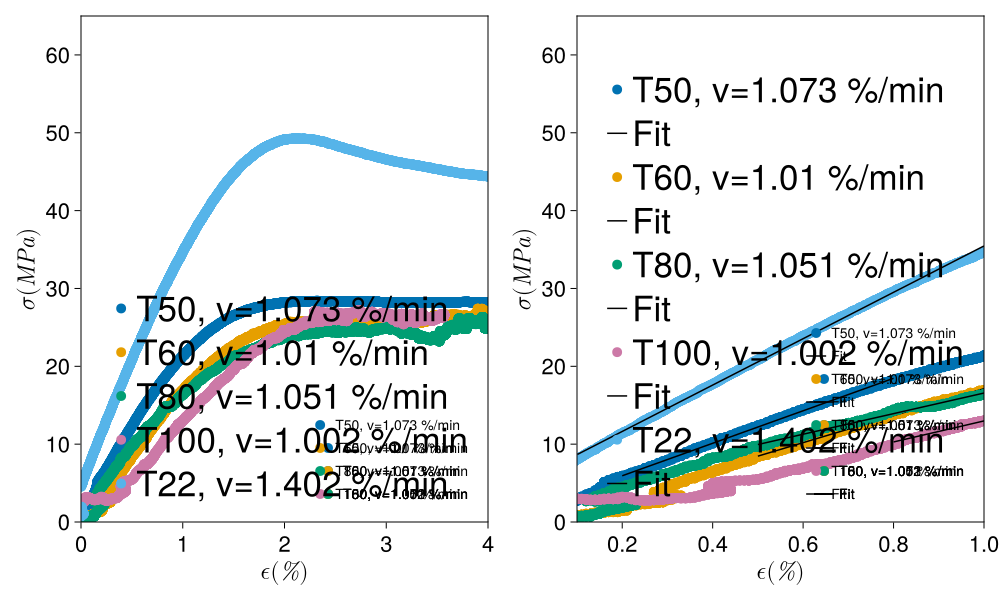

In [3211]:

aktuelldf=[]

for i in [ 1]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        push!(aktuelldf,df)
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3212]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,7.77176,47.7712,251006-1,2.0931,"[0.1009, 0.9999]",0.0898125,22,2.97888,49.28,34.7067,1.40248


In [3213]:
df=aktuelldf[1]

Row,Zeit,Weg,Kraft,Länge,dL_ORG,Name,Stress,Strain,Temperature
,Float64,Float64,Float64,Float64,Float64,String,Float64,Float64,Int64
1,0.22,0.02904,0.109,0.0018,0.0001,251006-1,0.726667,0.0001,22
2,0.24,0.02941,0.11,0.003,0.0013,251006-1,0.733333,0.0013,22
3,0.26,0.02967,0.114,0.003,0.0013,251006-1,0.76,0.0013,22
4,0.28,0.03014,0.116,0.0038,0.0021,251006-1,0.773333,0.0021,22
5,0.3,0.0305,0.117,0.0038,0.0021,251006-1,0.78,0.0021,22
6,0.32,0.03086,0.118,0.0048,0.0031,251006-1,0.786667,0.0031,22
7,0.34,0.03123,0.121,0.0048,0.0031,251006-1,0.806667,0.0031,22
8,0.36,0.03149,0.122,0.0076,0.0059,251006-1,0.813333,0.0059,22
9,0.38,0.03175,0.126,0.0094,0.0077,251006-1,0.84,0.0077,22


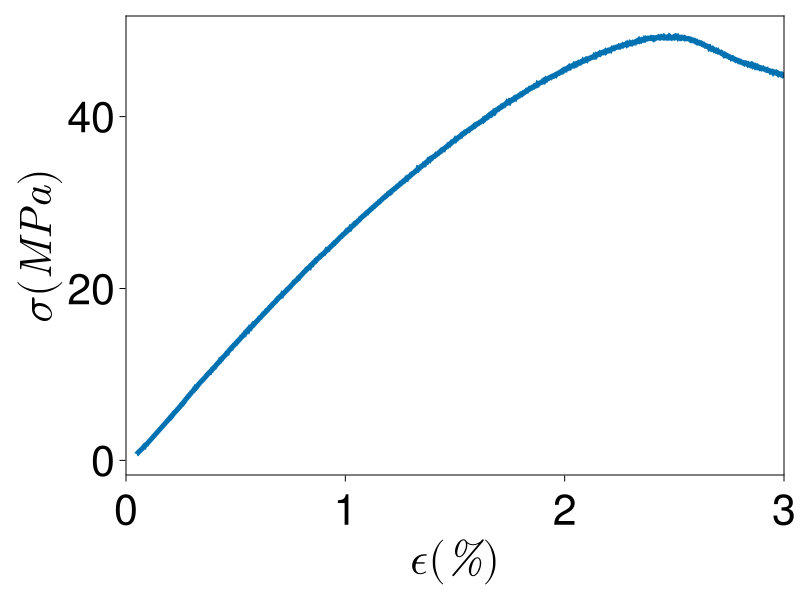

In [3214]:
Makie.lines!(axTemperaturen ,(df[!,:Weg])*100/60,df[!,:Stress];
linewidth=5, 
#color = :black,
clip = true,
marker = :rect,
label = L"T=22°C, v= 1,40 %.$\mathrm{min^{-1}}$")


# label = "T$(T), v=$(round(df_DataProperties[1," Strain Rate[%/min]"], digits=3)) %/min"

#axislegend(axStrainRate, labelsize=font-5, framevisible=false,position = :rb)
figTemperaturen

#### T40

In [3215]:

BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [3216]:
df_260126=[]

Any[]

In [3217]:
w=10*1e-3 # Width
t=15.5*1e-6 # thickness W4 from the 2nd batch
l=60*1e-3 # length between clamps
As=w*t    # stress section

1.55e-7

In [3218]:
ϵ_LinearRange=[0.5 1]
ϵ_range=[0 4]
t_range=[0 100] #in order to avoid wrong measurements from the camera
σ_range=[0 50]
T=40

40

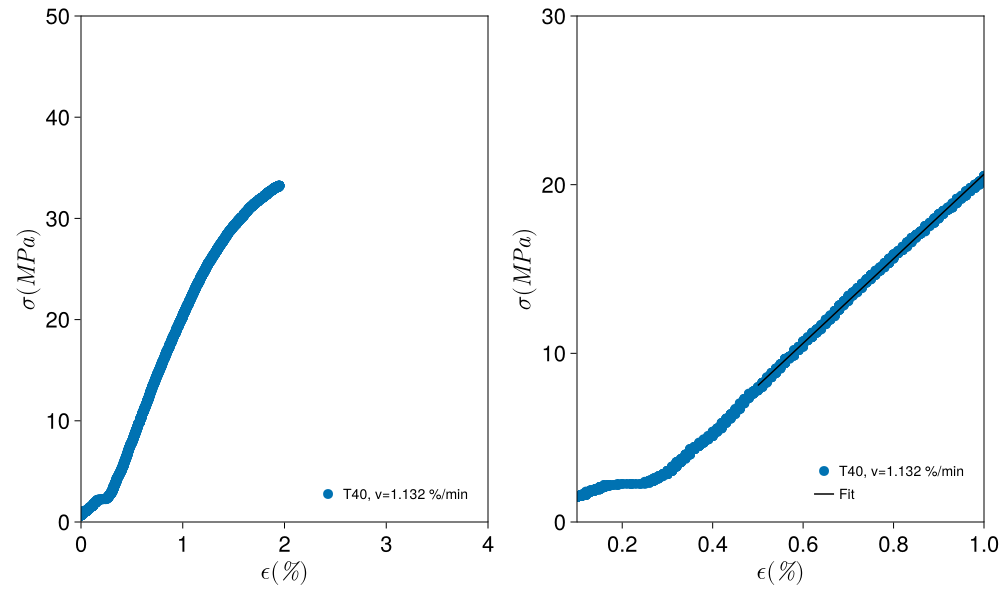

In [3219]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

aktuelldf=[]

for i in [3 ]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        
        limits!(ax1_Raum, 0, 4, 0, 50)


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, 0.1, 1,0,30)

        push!(DataProperties,properties)
        push!(aktuelldf,df)
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3220]:
df_DataProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
2,7.77176,47.7712,251006-1,2.0931,"[0.1009, 0.9999]",0.0898125,22,2.97888,49.28,34.7067,1.40248
3,14.8459,42.5532,251006-6,2.35,"[0.1, 1.0]",0.131207,22,3.31068,56.4667,34.8,4.33576
4,9.75169,41.841,251103-1,2.39,"[0.11, 1.0]",0.373016,22,3.75285,69.4667,42.1333,27.0283
5,4.29725,51.5464,260126-3,1.94,"[0.5, 1.0]",0.108925,40,2.5055,33.2258,20.5161,1.1322
6,1.99845,54.9451,260126-5,1.82,"[0.5, 1.0]",0.27083,40,2.71908,43.2903,31.6129,10.9466
7,4.7615,34.4828,260126-7,2.32,"[0.2, 0.8]",0.0955177,50,2.01977,27.5484,17.6774,1.07343
8,19.8779,45.4545,251103-5,2.2,"[0.1, 1.0]",0.749415,50,2.14537,31.2667,20.4,9.80967
9,17.1634,43.29,251103-7,2.31,"[0.1, 1.0]",0.612399,50,2.33842,35.7333,24.6667,25.4532


In [3221]:
df=aktuelldf[1]

Row,Zeit,Weg,Kraft,Länge,dL_ORG,Name,Stress,Strain,Temperature
,Float64,Float64,Float64,Float64,Float64,String,Float64,Float64,Int64
1,0.02,0.16,0.1,0.0,0.0,260126-3,0.645161,0.0,40
2,0.04,0.16,0.1,0.0,0.0,260126-3,0.645161,0.0,40
3,0.06,0.16,0.1,0.0,0.0,260126-3,0.645161,0.0,40
4,0.08,0.16,0.1,0.0,0.0,260126-3,0.645161,0.0,40
5,0.1,0.16,0.1,0.0,0.0,260126-3,0.645161,0.0,40
6,0.12,0.16,0.1,0.0,0.0,260126-3,0.645161,0.0,40
7,0.14,0.16,0.1,0.0,0.0,260126-3,0.645161,0.0,40
8,0.16,0.16,0.1,0.0,0.0,260126-3,0.645161,0.0,40
9,0.18,0.16,0.1,0.0,0.0,260126-3,0.645161,0.0,40


In [3222]:
#Makie.scatter!(axTemperaturen ,(df[!,:Weg])*100/60,df[!,:Stress];
#markersize=10, 
#color = :black,
#clip = true,
#marker = :rect,
#label = L"T=40°C, v= 1,13 %.$\mathrm{min^{-1}}$")


# label = "T$(T), v=$(round(df_DataProperties[1," Strain Rate[%/min]"], digits=3)) %/min"

#axislegend(axStrainRate, labelsize=font-5, framevisible=false,position = :rb)
#figTemperaturen

#### T50

In [3223]:

BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [3224]:
aktuellProperties=[]

Any[]

In [3225]:
## Geometrie
w=10*1e-3 # Width
t=15*1e-6 # thickness W4 from the 2nd batch
l=60*1e-3 # length between clamps
As=w*t    # stress section

1.5e-7

In [3226]:
ϵ_LinearRange=[0.2 0.8]
ϵ_range=[0 4]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 30]
T=50
aktuellProperties=[]

Any[]

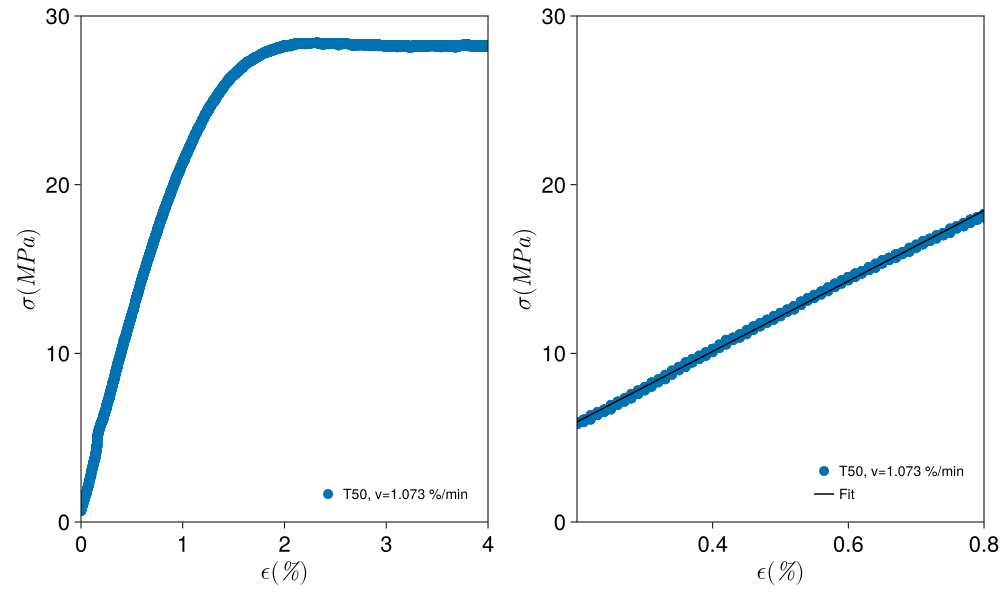

In [3227]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


aktuelldf=[]
for i in [ 7]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        push!(aktuelldf,df)
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3228]:
df=aktuelldf[1]

Row,Zeit,Weg,Kraft,Länge,dL_ORG,Name,Stress,Strain,Temperature
,Float64,Float64,Float64,Float64,Float64,String,Float64,Float64,Int64
1,0.02,0.04,0.1,0.0,0.0,260126-7,0.666667,0.0,50
2,0.04,0.04,0.1,0.0,0.0,260126-7,0.666667,0.0,50
3,0.06,0.04,0.1,0.0,0.0,260126-7,0.666667,0.0,50
4,0.08,0.04,0.1,0.0,0.0,260126-7,0.666667,0.0,50
5,0.1,0.04,0.1,0.0,0.0,260126-7,0.666667,0.0,50
6,0.12,0.04,0.1,0.0,0.0,260126-7,0.666667,0.0,50
7,0.14,0.04,0.1,0.0,0.0,260126-7,0.666667,0.0,50
8,0.16,0.04,0.1,0.0,0.0,260126-7,0.666667,0.0,50
9,0.18,0.04,0.1,0.0,0.0,260126-7,0.666667,0.0,50


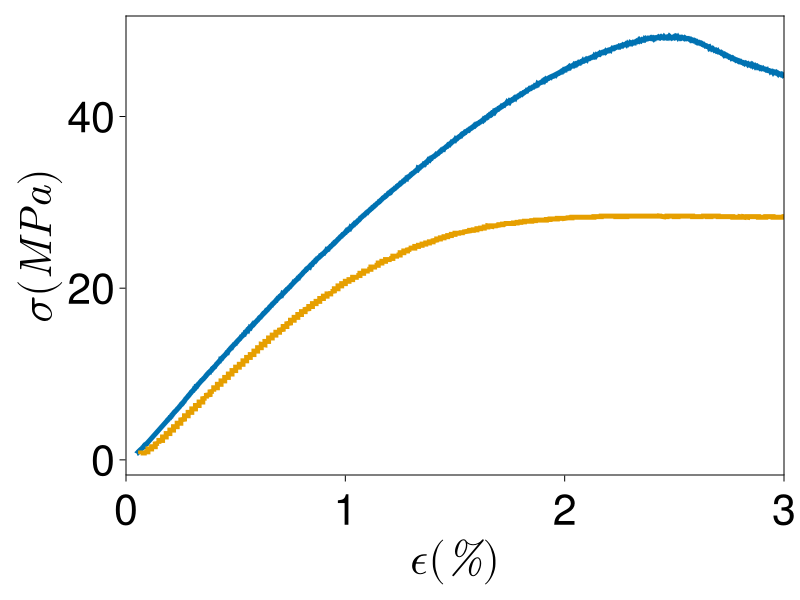

In [3229]:
Makie.lines!(axTemperaturen ,(df[!,:Weg])*100/60,df[!,:Stress];
linewidth=5, 
#color = :black,
clip = true,
marker = :rect,
label = L"T=50°C, v= 1.07 %.$\mathrm{min^{-1}}$")


# label = "T$(T), v=$(round(df_DataProperties[1," Strain Rate[%/min]"], digits=3)) %/min"

#axislegend(axTemperaturen, labelsize=font-5, framevisible=false,position = :rb)
figTemperaturen

#### T60

In [3230]:
BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [3231]:
df_260126=[]

Any[]

In [3232]:
aktuellProperties=[]

Any[]

In [3233]:
ϵ_LinearRange=[0.5 1]
ϵ_range=[0 4]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 35]
T=60
aktuellProperties=[]

Any[]

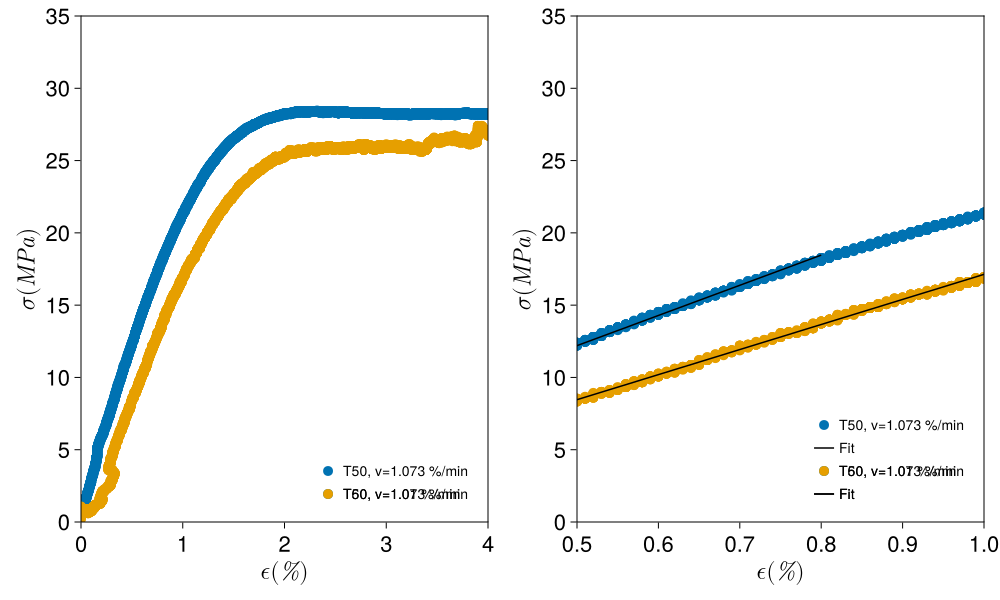

In [3234]:

aktuelldf=[]
for i in [ 10]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        push!(aktuelldf,df)
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3235]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,2.46872,25.641,260126-10,3.9,"[0.5, 1.0]",0.128125,60,1.73393,27.4,16.9333,1.00988


In [3236]:
df=aktuelldf[1]

Row,Zeit,Weg,Kraft,Länge,dL_ORG,Name,Stress,Strain,Temperature
,Float64,Float64,Float64,Float64,Float64,String,Float64,Float64,Int64
1,0.02,0.0,0.03,0.0,0.0,260126-10,0.2,0.0,60
2,0.04,0.0,0.04,0.0,0.0,260126-10,0.266667,0.0,60
3,0.06,0.01,0.06,0.0,0.0,260126-10,0.4,0.0,60
4,0.08,0.01,0.08,0.0,0.0,260126-10,0.533333,0.0,60
5,0.1,0.01,0.1,0.0,0.0,260126-10,0.666667,0.0,60
6,0.12,0.01,0.12,0.0,0.0,260126-10,0.8,0.0,60
7,0.14,0.01,0.15,0.0,0.0,260126-10,1.0,0.0,60
8,0.16,0.01,0.16,0.0,0.0,260126-10,1.06667,0.0,60
9,0.18,0.01,0.16,0.0,0.0,260126-10,1.06667,0.0,60


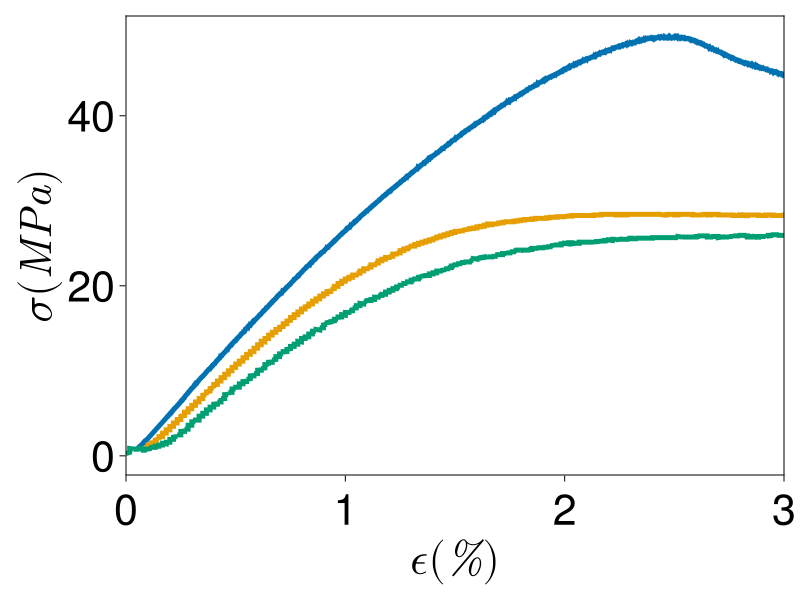

In [3237]:
Makie.lines!(axTemperaturen ,(df[!,:Weg])*100/60,df[!,:Stress];
linewidth=5,  
#color = :black,
clip = true,
marker = :rect,
label = L"T=60°C, v= 1,01 %.$\mathrm{min^{-1}}$")


# label = "T$(T), v=$(round(df_DataProperties[1," Strain Rate[%/min]"], digits=3)) %/min"

#axislegend(axTemperaturen, labelsize=font-5, framevisible=false,position = :rb)
figTemperaturen

#### T80

In [3238]:

BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [3239]:
df_260126=[]

Any[]

In [3240]:
aktuellProperties=[]

Any[]

In [3241]:
ϵ_LinearRange=[0.5 1]
ϵ_range=[0 4]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 35]
T=80
aktuellProperties=[]

Any[]

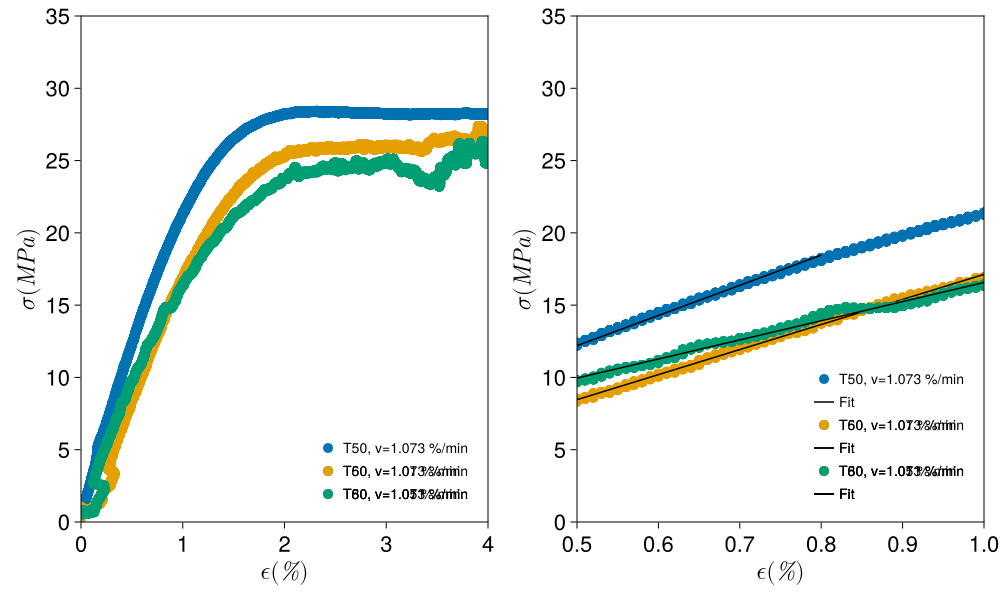

In [3242]:


aktuelldf=[]

for i in [ 13]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        push!(aktuelldf,df)
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3243]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,3.53694,25.3807,260126-13,3.94,"[0.5, 1.0]",0.301246,80,1.32312,26.3333,16.4667,1.0511


In [3244]:
df=aktuelldf[1]

Row,Zeit,Weg,Kraft,Länge,dL_ORG,Name,Stress,Strain,Temperature
,Float64,Float64,Float64,Float64,Float64,String,Float64,Float64,Int64
1,0.02,0.0,0.07,0.0,0.0,260126-13,0.466667,0.0,80
2,0.04,0.01,0.08,0.0,0.0,260126-13,0.533333,0.0,80
3,0.06,0.01,0.1,0.0,0.0,260126-13,0.666667,0.0,80
4,0.08,0.01,0.11,0.0,0.0,260126-13,0.733333,0.0,80
5,0.1,0.01,0.12,0.0,0.0,260126-13,0.8,0.0,80
6,0.12,0.01,0.11,0.0,0.0,260126-13,0.733333,0.0,80
7,0.14,0.01,0.11,0.0,0.0,260126-13,0.733333,0.0,80
8,0.16,0.01,0.12,0.0,0.0,260126-13,0.8,0.0,80
9,0.18,0.01,0.12,0.0,0.0,260126-13,0.8,0.0,80


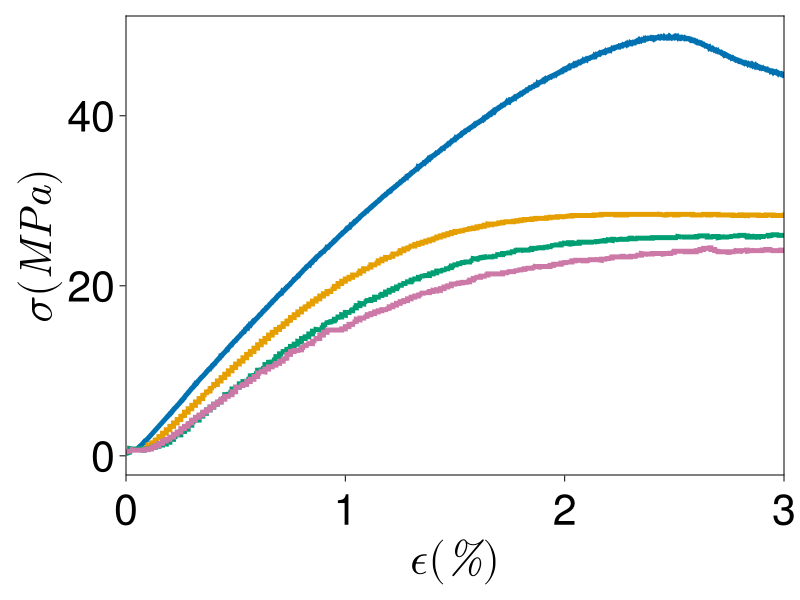

In [3245]:
Makie.lines!(axTemperaturen ,(df[!,:Weg])*100/60,df[!,:Stress];
linewidth=5, 
#color = :black,
clip = true,
marker = :rect,
label = L"T=80°C, v= 1,05 %.$\mathrm{min^{-1}}$")


# label = "T$(T), v=$(round(df_DataProperties[1," Strain Rate[%/min]"], digits=3)) %/min"

#axislegend(axTemperaturen, labelsize=font-5, framevisible=false,position = :rb)
figTemperaturen

#### T100

In [3246]:

BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [3247]:
df_260126=[]

Any[]

In [3248]:
aktuellProperties=[]

Any[]

In [3249]:
ϵ_LinearRange=[0.8 1.5]
ϵ_range=[0 4]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 35]
T=100
aktuellProperties=[]

Any[]

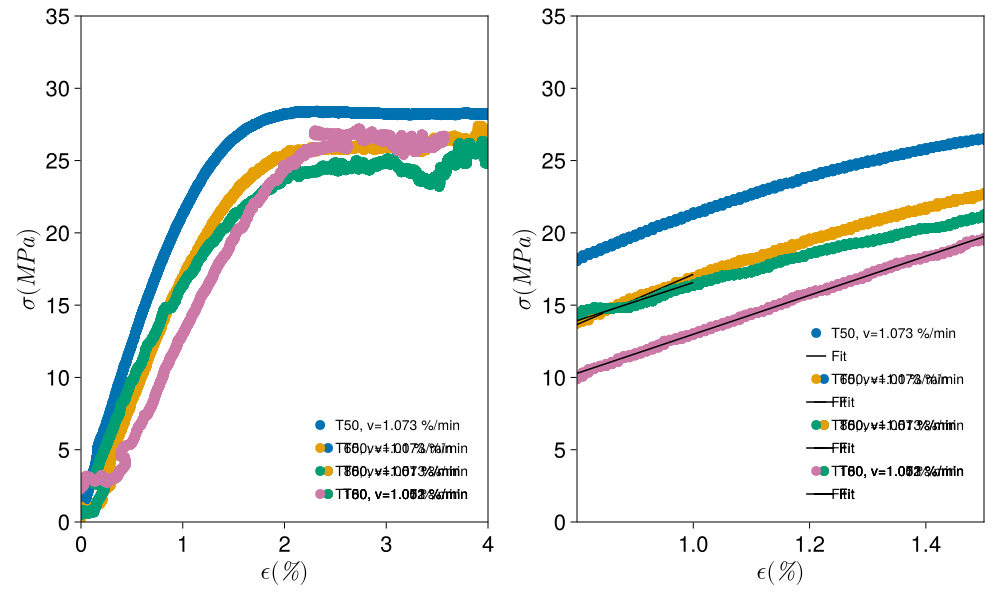

In [3250]:

aktuelldf=[]
for i in [ 15]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        push!(aktuelldf,df)
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [3251]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,4.21749,54.9451,260126-15,2.73,"[0.8, 1.5]",0.0862335,100,1.35054,27.2,19.6667,1.00169


In [3252]:
df=aktuelldf[1]

Row,Zeit,Weg,Kraft,Länge,dL_ORG,Name,Stress,Strain,Temperature
,Float64,Float64,Float64,Float64,Float64,String,Float64,Float64,Int64
1,0.02,0.0,0.34,0.0,0.0,260126-15,2.26667,0.0,100
2,0.04,0.0,0.35,0.0,0.0,260126-15,2.33333,0.0,100
3,0.06,0.01,0.36,0.0,0.0,260126-15,2.4,0.0,100
4,0.08,0.01,0.37,0.0,0.0,260126-15,2.46667,0.0,100
5,0.1,0.01,0.37,0.0,0.0,260126-15,2.46667,0.0,100
6,0.12,0.01,0.37,0.0,0.0,260126-15,2.46667,0.0,100
7,0.14,0.01,0.38,0.0,0.0,260126-15,2.53333,0.0,100
8,0.16,0.01,0.38,0.0,0.0,260126-15,2.53333,0.0,100
9,0.18,0.01,0.38,0.0,0.0,260126-15,2.53333,0.0,100


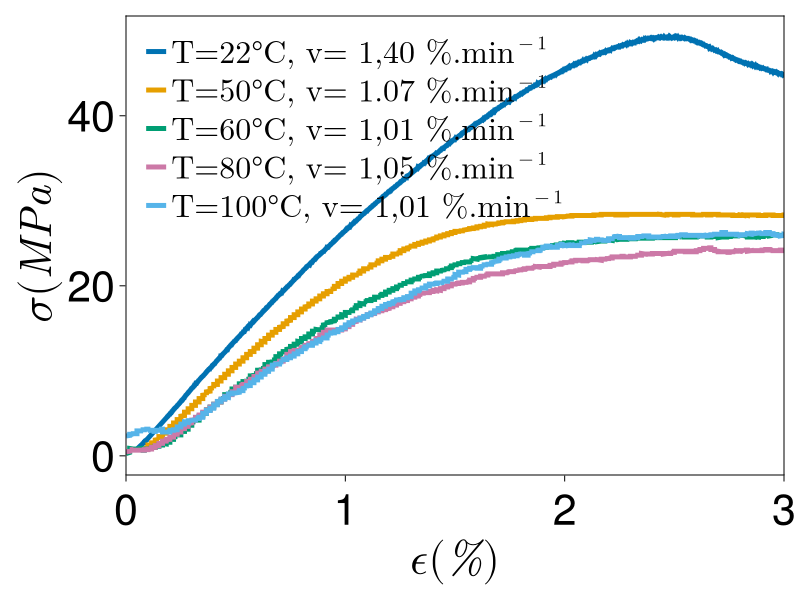

In [3253]:
Makie.lines!(axTemperaturen ,(df[!,:Weg])*100/60,df[!,:Stress];
linewidth=5, 
#color = :black,
clip = true,
marker = :rect,
label = L"T=100°C, v= 1,01 %.$\mathrm{min^{-1}}$")


# label = "T$(T), v=$(round(df_DataProperties[1," Strain Rate[%/min]"], digits=3)) %/min"

axislegend(axTemperaturen, labelsize=font+8, framevisible=false,position = :lt)
figTemperaturen